# Configurable export of the six-dataset motor-imagery cohort


**One environment-specific consideration, upfront:** Google Drive is mounted through
a FUSE filesystem, not a real local disk. Two consequences worth knowing before a
long unattended run:

1. **Random-access reads are slower than local disk.** MOABB/MNE readers do seek
   operations while parsing EDF/MAT/FIF files, which is where FUSE overhead is most
   noticeable. `MIRROR_RAW_DATA_LOCALLY` (below) controls this: `True` copies each
   dataset's files to the Colab VM's local disk the first time they're touched
   (`/content/mne_data`), then reads from there for every subsequent subject --
   trading ~one-time copy cost for much faster repeated access. `False` reads
   directly from Drive every time, which is closer to a literal "process the data
   in place on Drive" but slower and more prone to (2).
2. **Frequent small writes to Drive intermittently fail with transient I/O errors**
   -- a known FUSE behavior, not a bug in this notebook. Every write in Sections
   5-8 (shards, checkpoint, metadata, QC report, splits, manifest) goes through
   `_write_with_retry`, defined below, which retries with exponential backoff. This
   is the Colab-specific reason that function exists at all (on Kaggle's local
   disk, in the other version of this notebook, it is a harmless pass-through).

---
**Changes in this revision (v4) -- the export itself is untouched: shards (`X`, `X_z`, `trial_mu`, `trial_sigma`), metadata and `preproc_id` are exactly what v3 produces, so a completed v3 `processed/` folder resumes without re-export**

1. **New module `preprocessing_pkg.standardization`** (upload the updated `preprocessing_pkg.zip`). It holds the standard distribution template: fit, apply, serialize, a loader, an augmenter, validation tools and a 24-check synthetic self-test.
2. **`StandardizationConfig`** added to `ExportConfig` (field `standard`). It does NOT enter `preproc_id()` because it changes no stored number. `SplitConfig.adopt_existing_locked_test` added (default `True`).
3. **Section 8: locked-test freeze guard** (one new cell between the two existing split cells). If `splits/locked_test_subjects.json` already exists, the locked set can no longer change silently.
4. **New Section 9 -- Standard distribution template**: per-trial scale sidecar, level diagnostics, template fit on the CV pool only, held-out validation, residual dataset-fingerprint probe, amplitude gate, Cho2017 diagnostics, acceptance tests on real shards, and the exported artifacts (`config/standard_template.json`, `code/standardization.py`, QC report, figure, sidecars).
5. **Final gate** now also requires Section 9 to pass; `manifest.json` gains `standardization_status`, `standard_template_path`, `standard_template_sha1`. The old "Section 9 -- Summary" is now Section 10.
6. `run_name` -> `eeg_export_v4`. All stored cell outputs were cleared (they described the v3 run).

*Observed and deliberately NOT changed* (see the Section 9 diagnostics cell): `_cho2017_qc_mask` calls `get_cho2017_bad_trial_indices(subject)` without the required `mat_path`, inside a bare `except`, so Cho2017 author bad-trial exclusion is a silent no-op in this export; and the export loop contains a hard-coded `n_jobs = 2`.

---
**Previous revision (v3)**

1. **Band-pass 8-32 Hz** is now the `PreprocConfig` class default as well as the `CFG` value (they previously disagreed: 8-30 vs 8-32).
2. **Per-trial channel-wise z-score** stored as `X_z` next to the untouched raw `X`, plus `trial_mu` / `trial_sigma` (Section 1 explains the safeguards). QC 1 and QC 4 verify it.
3. **Master window unchanged (0-3 s, 384 samples)**; any crop/ablation happens at train level.
4. **`metadata/stored_layout.json`** (also summarised in `manifest.json`) records `n_samples`, `n_channels`, `target_sfreq`, `master_window_sec`, band, array schema and the z-score spec, so downstream code reads the geometry instead of hard-coding it. `subjects.parquet` gains `n_samples`, `n_channels`, `trial_norm`, `n_flat_real_trial_channels`; QC flags any shard whose geometry differs from the config.
5. **`feedback_confounded`** column in `trials.parquet` (Dreyer2023 runs other than R1/R2). All runs are still exported (`dreyer2023_acquisition_only` default unchanged); filter this column at load time.
6. **Validation subjects are drawn per dataset** in the pooled folds (previously a pooled random draw could omit small datasets).
7. **Stale-checkpoint guard**: a checkpoint written under a different `preproc_id` is discarded, so old shards are never silently reused. `datasets_summary.n_exported` now also counts resumed subjects.
8. `run_name` -> `eeg_export_v3`; stored cell outputs were cleared because they described the previous export.


In [ ]:
import os, sys, shutil, stat, json, hashlib, gc, time, warnings
from pathlib import Path
from dataclasses import dataclass, field, asdict, fields, is_dataclass
from typing import Any, Optional

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")


In [ ]:
from zipfile import ZipFile

with ZipFile("/content/preprocessing_pkg-2.zip", 'r') as zObject:
    zObject.extractall(path="/content")

### Edit these paths, then run the rest of the notebook top to bottom

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)


Mounted at /content/drive


In [ ]:
PKG_SOURCE_DIR = Path("/content/preprocessing_pkg")
RAW_DATA_DRIVE_ROOT = Path("/content/drive/MyDrive/MI_EEG_Datasets")
OUTPUT_DRIVE_ROOT = Path("/content/drive/MyDrive/MI_EEG_Datasets/Processed")

# See the Section 0 markdown above for what this trades off.
MIRROR_RAW_DATA_LOCALLY = False

for p, desc in [(PKG_SOURCE_DIR, "PKG_SOURCE_DIR"), (RAW_DATA_DRIVE_ROOT, "RAW_DATA_DRIVE_ROOT")]:
    assert p.exists(), f"{desc} does not exist: {p} -- fix the path above."
OUTPUT_DRIVE_ROOT.mkdir(parents=True, exist_ok=True)
print("Drive mounted. Paths:")
print(" PKG_SOURCE_DIR      :", PKG_SOURCE_DIR)
print(" RAW_DATA_DRIVE_ROOT  :", RAW_DATA_DRIVE_ROOT)
print(" OUTPUT_DRIVE_ROOT    :", OUTPUT_DRIVE_ROOT)
print(" MIRROR_RAW_DATA_LOCALLY:", MIRROR_RAW_DATA_LOCALLY)


Drive mounted. Paths:
 PKG_SOURCE_DIR      : /content/preprocessing_pkg
 RAW_DATA_DRIVE_ROOT  : /content/drive/MyDrive/MI_EEG_Datasets
 OUTPUT_DRIVE_ROOT    : /content/drive/MyDrive/MI_EEG_Datasets/Processed
 MIRROR_RAW_DATA_LOCALLY: False


In [ ]:
!pip install -q mne moabb pyriemann autoreject umap-learn mne-icalabel python-picard psutil pyyaml


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 980.1/980.1 kB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.6/153.6 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.8/48.8 MB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.2/120.2 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.0/258.0 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.5/202.5 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.6/73.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0

In [ ]:
import mne
mne.set_log_level("ERROR")

# Import preprocessing_pkg SUBMODULES
if str(PKG_SOURCE_DIR.parent) not in sys.path:
    sys.path.insert(0, str(PKG_SOURCE_DIR.parent))
package_import_name = PKG_SOURCE_DIR.name   # must be "preprocessing_pkg" for the imports below to resolve
assert package_import_name == "preprocessing_pkg", (
    f"PKG_SOURCE_DIR's folder is named {package_import_name!r}; rename it to "
    f"'preprocessing_pkg' or symlink it, since the imports below assume that name.")

import preprocessing_pkg.config as pkgconfig
import preprocessing_pkg.channels as pkgchannels
import preprocessing_pkg.io_loaders as pkgio
import preprocessing_pkg.signal_processing as pkgsp
import preprocessing_pkg.pipeline_builder as pkgpb
import preprocessing_pkg.alignment as pkgalign
import preprocessing_pkg.audits as pkgaudits
import preprocessing_pkg.cho2017_qc as pkgcho
import preprocessing_pkg.standardization as pkgstd   # v4: standard distribution template

import moabb
print("preprocessing_pkg submodules imported directly (no torch/pyriemann dependency).")
print("mne", mne.__version__, "| moabb", moabb.__version__)


preprocessing_pkg submodules imported directly (no torch/pyriemann dependency).
mne 1.13.2 | moabb 1.7.2


In [ ]:
# --- Point MNE/MOABB at the raw-data cache -------------------------------------------
SIGNAL_EXTENSIONS = {'.edf', '.mat', '.fif', '.set', '.fdt', '.vhdr', '.vmrk', '.eeg', '.pdf', '.bdf', '.gdf'}

drive_mne_data_candidates = list(RAW_DATA_DRIVE_ROOT.rglob("mne_data"))
assert drive_mne_data_candidates, f"No 'mne_data' folder found under {RAW_DATA_DRIVE_ROOT}."
DRIVE_MNE_DATA_DIR = drive_mne_data_candidates[0]

if MIRROR_RAW_DATA_LOCALLY:
    # Local mirror on the Colab VM's own disk, built once. Small metadata/index files
    # are copied outright; large signal files are SYMLINKED (not copied) back to
    # Drive -- this keeps the one-time mirror step fast and avoids doubling Drive
    # storage use, while still giving MNE/MOABB fast local directory listings and
    # metadata access. The bytes of large recordings are still ultimately read from
    # Drive on first access, but MNE's own on-disk cache (Section below) then keeps
    # anything it touches locally for every subsequent subject.
    MNE_DATA_DIR = Path('/content/mne_data')
    MNE_DATA_DIR.mkdir(parents=True, exist_ok=True)
    n_copied = n_linked = n_skipped = 0
    for root, dirs, files in os.walk(DRIVE_MNE_DATA_DIR):
        rel_path = Path(root).relative_to(DRIVE_MNE_DATA_DIR)
        dest_dir = MNE_DATA_DIR / rel_path
        dest_dir.mkdir(parents=True, exist_ok=True)
        for filename in files:
            src_file, dest_file = Path(root) / filename, dest_dir / filename
            if dest_file.exists() or dest_file.is_symlink():
                n_skipped += 1
                continue
            if src_file.suffix.lower() in SIGNAL_EXTENSIONS:
                try:
                    dest_file.symlink_to(src_file)
                    n_linked += 1
                except FileExistsError:
                    pass
            else:
                shutil.copyfile(src_file, dest_file)
                os.chmod(dest_file, dest_file.stat().st_mode | stat.S_IWRITE)
                n_copied += 1
    print(f"Local mirror built at {MNE_DATA_DIR}: {n_copied} small files copied, "
          f"{n_linked} large files symlinked, {n_skipped} already present.")
else:
    MNE_DATA_DIR = DRIVE_MNE_DATA_DIR
    print(f"Reading raw data directly from Drive (no local mirror): {MNE_DATA_DIR}")

MNE_DATA_DIR_STR = str(MNE_DATA_DIR)
PHYSIONET_DIR = os.path.join(MNE_DATA_DIR_STR, 'MNE-eegbci-data', 'files', 'eegmmidb', '1.0.0')
mne.set_config('MNE_DATA', MNE_DATA_DIR_STR)
mne.set_config('MNE_DATASETS_EEGBCI_PATH', MNE_DATA_DIR_STR)
moabb.set_download_dir(MNE_DATA_DIR_STR)
os.environ['PHYSIONET_ROOT'] = PHYSIONET_DIR
print("MNE_DATA:", MNE_DATA_DIR_STR)


Reading raw data directly from Drive (no local mirror): /content/drive/MyDrive/MI_EEG_Datasets/mne_data
MNE_DATA: /content/drive/MyDrive/MI_EEG_Datasets/mne_data


In [ ]:
# Pipeline's own on-disk cache (filter design cache etc.) -- always LOCAL regardless
# of MIRROR_RAW_DATA_LOCALLY, since these are small, ephemeral, and read/written
# extremely frequently (exactly the write pattern most likely to hit transient Drive
# FUSE errors, and least valuable to persist across sessions anyway).
OUTPUT_ROOT = OUTPUT_DRIVE_ROOT   # Sections 3+ write shards/metadata/QC/etc. here, on Drive
CACHE_DIR = "/content/pipeline_cache"
os.makedirs(CACHE_DIR, exist_ok=True)
pkgsp.configure_cache(CACHE_DIR)
DEFAULT_OUTPUT_ROOT = str(OUTPUT_DRIVE_ROOT)   # Section 1's ExportConfig reads this
print("Output root (on Drive):", OUTPUT_ROOT)
print("Local scratch cache:", CACHE_DIR)


[cache] Disk cache enabled at: /content/pipeline_cache
Output root (on Drive): /content/drive/MyDrive/MI_EEG_Datasets/Processed
Local scratch cache: /content/pipeline_cache


In [ ]:
# Every write in Sections 5-8 goes through this. Drive's FUSE layer intermittently
# raises transient OSErrors ("Input/output error", "Transport endpoint is not
# connected") under frequent small writes -- this retries with exponential backoff
# before giving up. See the Section 0 markdown for context.
def _write_with_retry(fn, *args, retries=6, initial_delay=2.0, **kwargs):
    delay = initial_delay
    last_exc = None
    for attempt in range(retries):
        try:
            return fn(*args, **kwargs)
        except OSError as exc:
            last_exc = exc
            print(f"  [Drive IO retry {attempt+1}/{retries}] {type(exc).__name__}: {exc}; "
                  f"retrying in {delay:.1f}s")
            time.sleep(delay)
            delay *= 2
    raise RuntimeError(
        f"Write failed after {retries} attempts against Drive -- this usually means "
        f"more than a transient hiccup (session re-auth needed, quota, or a broken "
        f"path). Re-run the drive.mount() cell above and try again."
    ) from last_exc


## Section 1 — Full configuration

Every value below can be changed. Two groups, deliberately kept separate:

- **`PreprocConfig`** — anything that changes the *numbers written to disk*
  (sampling rate, band-pass, harmonization mode, CAR scope, artifact variant, the
  master epoch window). Changing any of these fields changes `preproc_id()`, a short
  hash stamped into every output file, so two exports with different settings can
  never be silently mixed.
- **Everything else** (`DatasetSelectConfig`, `RamConfig`, `SplitConfig`, `QCConfig`)
  — knobs that do not change what is stored, only which subjects are included, how
  the export loop schedules work, how splits are drawn, and what QC treats as a
  pass/fail threshold.

**Normalization policy (revised).** `X` is always stored as raw physical units (uV,
float32) and is never modified. *Fitted* normalization (per-channel mean/std estimated over a
set of training trials) and Euclidean Alignment are still NOT baked in: which trials count as
"training" depends on the split, and baking them in would let held-out subjects touch statistics
from themselves. `EA_ENABLED` only controls whether a per-subject spatial-covariance reference is
*computed and stored as metadata* -- it is never applied to `X`.

**Per-trial channel-wise z-score IS now stored, next to `X`, never instead of it.** It has no
fitted quantity: each trial/channel is normalized with its own time-axis mean and std, so no
other trial, subject or split can influence it (QC 1 re-checks this by recomputing on a
reordered subset). Care taken, one point per known failure mode:

- **Raw is kept.** `X` (uV) stays untouched, so amplitude-based QC, EA references and any
  raw-unit ablation remain possible. `trial_mu` / `trial_sigma` (uV) are stored per trial and
  channel, so the amplitude information z-scoring removes is recoverable, not lost.
- **Masked channels stay exactly zero** (`mu=0`, `sigma=1` recorded), so the never-recorded-channel
  mask is not turned into a fake signal. Real-but-flat channels (`std <= zscore_eps_uv`) are treated
  the same way and counted (`n_flat_real_trial_channels`), never divided by ~0.
- **The statistic is computed over the full stored master window** (`0-3 s`), in float64, after the
  uV conversion and after the explicit truncation to `N_SAMPLES`. If a train-level ablation crops
  the window, `X_z[..., crop]` is *not* z-scored over the crop: recompute it from the raw `X`
  with the same formula (documented in `metadata/stored_layout.json`). Do not treat gains from a
  new window and from z-scoring as additive; re-evaluate the combination.
- **Z-score removes between-channel power ratios** (e.g. the C3/C4 asymmetry) as well as absolute
  scale. `trial_sigma` preserves them; whether to feed them back is a train-level ablation.
- `store_zscore_array=False` stores only `trial_mu`/`trial_sigma` (about 2x smaller shards);
  `X_z` is then recomputed at load time by the same formula.


In [ ]:
def _canon(obj: Any) -> str:
    return json.dumps(obj, sort_keys=True, separators=(",", ":"), default=list)


@dataclass(frozen=True)
class DatasetSelectConfig:
    '''Per-dataset knobs that decide WHICH raw data is used. None of these change
    the numbers computed FROM a trial, only which trials/subjects are included.'''
    enabled: bool = True
    subjects: Any = "all"                 # "all" | int (first N) | explicit list[int]
    extra_excluded_subjects: tuple = ()    # on top of the package's documented exclusions
    lee2019_sessions: tuple = (1, 2)       # BOTH offline sessions by default (required)
    dreyer2023_acquisition_only: bool = False
    # False (default): keep all 6 runs. Run-level provenance (Section 4) records which
    # run every trial came from, so the feedback-confound runs (R3-R6, feedback from
    # cue+1.25s) can be filtered out at LOAD time instead of discarded at export time.
    # Set True to reproduce the main notebook's documented acquisition-only default.
    physionet_allow_anomalous: bool = False


@dataclass(frozen=True)
class PreprocConfig:
    '''Everything that changes the numbers written into the stored arrays.
    Hashed into preproc_id(); changing any field invalidates old exports.'''
    version: str = "v1"
    target_sfreq: float = 128.0
    bandpass: tuple = (8.0, 32.0)
    fir_trans_bandwidth: float = 2.0
    montage_name: str = "standard_1005"
    harmonization_mode: str = "reference_masked"   # "reference_masked" | "union" | "intersection"
    anchor_datasets: tuple = ("physionet", "cho2017")
    car_scope: str = "shared_support"               # "shared_support" | "native"
    artifact_variant: str = "primary"                # "primary" | "ica" | "autoreject" | "channel_reject"
    # Cue-relative [tmin, tmax) of the MASTER epoch stored on disk. Wider than any one
    # analysis window on purpose: a window ablation becomes a load-time CROP of this,
    # never a re-export. Validated against every enabled dataset's own trial_length_sec
    # / pre_cue_clean_sec in Section 3 before export starts.
    master_window: tuple = (0.0, 3.0)
    units: str = "uV"
    dtype: str = "float32"
    label_map: dict = field(default_factory=lambda: {"left_hand": 0, "right_hand": 1})
    random_state: int = 42
    ea_enabled: bool = True     # compute + store per-subject EA reference as METADATA only
    ea_scope: str = "subject"   # documents which scope the stored reference matches
    # Per-trial channel-wise z-score (time axis, ddof=0). Label-free, no fitted statistic, so it is
    # safe to store at export time. Stored NEXT TO the raw X, never instead of it.
    trial_norm: str = "zscore_per_trial_channel"   # "zscore_per_trial_channel" | "none"
    zscore_eps_uv: float = 1e-6      # std at or below this (uV) marks a channel/trial as flat -> stays 0
    store_zscore_array: bool = True  # False: keep only trial_mu / trial_sigma (X_z recomputable)

    def __post_init__(self):
        if self.dtype != "float32":
            raise ValueError("Store float32 -- values are in uV; float16 risks over/underflow.")
        if self.units != "uV":
            raise ValueError("units must be 'uV' (converted from MNE's native Volts at export).")
        span = (self.master_window[1] - self.master_window[0]) * self.target_sfreq
        if abs(span - round(span)) > 1e-6:
            raise ValueError(f"master_window does not give an integer sample count ({span}).")
        if self.trial_norm not in ("zscore_per_trial_channel", "none"):
            raise ValueError(f"trial_norm must be 'zscore_per_trial_channel' or 'none', got {self.trial_norm!r}.")
        if not self.zscore_eps_uv > 0:
            raise ValueError("zscore_eps_uv must be > 0.")

    @property
    def n_samples(self) -> int:
        return int(round((self.master_window[1] - self.master_window[0]) * self.target_sfreq))

    def preproc_id(self) -> str:
        return hashlib.sha1(_canon(asdict(self)).encode()).hexdigest()[:12]


@dataclass(frozen=True)
class RamConfig:
    '''Export-time performance / memory-safety knobs. Subjects are processed in
    parallel (n_jobs chosen from live free RAM, see Section 5) and each one writes
    immediately to disk; this controls how that loop schedules work, never whether
    results depend on it -- output is identical regardless of n_jobs or chunking.'''
    n_jobs: int = 1                    # sequential by default
    free_ram_reserve_gb: float = 2.0
    per_worker_gb_budget: float = 1.5
    resume: bool = True                # skip subjects whose shard already exists + verifies
    gc_every_subject: bool = True
    lee2019_process_sessions_separately: bool = True  # halves peak RAM for the one native-1000Hz dataset


@dataclass(frozen=True)
class SplitConfig:
    '''Subject-level, leakage-free split manifest parameters (Section 8).'''
    protocol: str = "pooled_group_kfold"
    n_folds: int = 5
    val_frac: float = 0.15
    locked_test_frac: float = 0.15
    stratify_by_dataset: bool = True
    seed: int = 42
    # v4: if splits/locked_test_subjects.json already exists and differs from the set drawn below, ADOPT the file's set
    # (True) or raise (False). The locked test set must never change after the first export.
    adopt_existing_locked_test: bool = True


@dataclass(frozen=True)
class QCConfig:
    '''Thresholds the QC gate checks against (Section 7). Exceeding these does not
    crash the export -- it marks qc_status='fail'/'warn' per subject and dataset, and
    a 'fail' anywhere blocks the final READY_FOR_TRAINING status.'''
    amplitude_median_abs_uv_min: float = 0.5
    amplitude_median_abs_uv_max: float = 500.0
    max_nan_fraction: float = 0.0
    min_trials_per_class: int = 5
    max_class_imbalance_ratio: float = 3.0
    require_masked_exactly_zero: bool = True
    require_deterministic_rebuild: bool = True
    n_determinism_check_subjects: int = 3


@dataclass(frozen=True)
class ExportConfig:
    run_name: str = "eeg_export_v1"
    output_root: str = field(default_factory=lambda: DEFAULT_OUTPUT_ROOT)
    seed: int = 42
    datasets: dict = field(default_factory=lambda: {
        "physionet": DatasetSelectConfig(),
        "cho2017": DatasetSelectConfig(),
        "lee2019": DatasetSelectConfig(),
        "bnci2014001": DatasetSelectConfig(),
        "weibo2014": DatasetSelectConfig(),
        "dreyer2023": DatasetSelectConfig(),
    })
    preproc: PreprocConfig = field(default_factory=PreprocConfig)
    ram: RamConfig = field(default_factory=RamConfig)
    split: SplitConfig = field(default_factory=SplitConfig)
    qc: QCConfig = field(default_factory=QCConfig)
    # v4: parameters of the standard distribution template (Section 9). Does not enter PreprocConfig.preproc_id().
    standard: Any = field(default_factory=lambda: pkgstd.StandardizationConfig())

    def enabled_dataset_names(self) -> list:
        return [k for k, v in self.datasets.items() if v.enabled]

    def to_jsonable(self) -> dict:
        def conv(o):
            if is_dataclass(o):
                return {k: conv(v) for k, v in asdict(o).items()}
            if isinstance(o, dict):
                return {k: conv(v) for k, v in o.items()}
            if isinstance(o, (list, tuple)):
                return [conv(v) for v in o]
            return o
        return conv(self)


### Edit configuration

Every field has a default matching the main notebook's primary pipeline; override only what you want to change.
Examples of common overrides are commented in place.

In [ ]:
CFG = ExportConfig(
    run_name="eeg_export_v4",
    output_root=DEFAULT_OUTPUT_ROOT,
    seed=42,

    datasets={
        "physionet":   DatasetSelectConfig(subjects="all"),
        "cho2017":     DatasetSelectConfig(subjects="all"),
        "lee2019":     DatasetSelectConfig(subjects="all", lee2019_sessions=(1, 2)),   # BOTH sessions
        "bnci2014001": DatasetSelectConfig(subjects="all"),
        "weibo2014":   DatasetSelectConfig(subjects="all"),
        "dreyer2023":  DatasetSelectConfig(subjects="all", dreyer2023_acquisition_only=False),
    },

    preproc=PreprocConfig(
        target_sfreq=128.0,
        bandpass=(8.0, 32.0),               # <- analysis band (FROZEN 8-32 Hz; class default now matches)
        fir_trans_bandwidth=2.0,
        montage_name="standard_1005",
        harmonization_mode="reference_masked",   # <- "union" | "intersection" | "reference_masked"
        anchor_datasets=("physionet", "cho2017"),
        car_scope="shared_support",
        artifact_variant="primary",          # <-  "primary" | "ica" | "autoreject" | "channel_reject"
        master_window=(0.0, 3.0),            # <- wide master epoch; crop at load time
        ea_enabled=True,                     # <- compute+store EA reference as metadata only
        ea_scope="subject",
        trial_norm="zscore_per_trial_channel",   # stored next to raw X (see Section 1 policy)
        zscore_eps_uv=1e-6,
        store_zscore_array=True,
    ),

    ram=RamConfig(
        n_jobs=2,                            # sequential export; see Section 6 for why
        resume=True,
        lee2019_process_sessions_separately=True,
    ),

    split=SplitConfig(
        n_folds=5,
        val_frac=0.15,
        locked_test_frac=0.15,
        seed=42,
        adopt_existing_locked_test=True,   # v4: never silently re-draw the locked test set
    ),

    qc=QCConfig(),

    # v4: standard distribution template. Defaults are the values derived from the distribution analysis:
    #   deadband 3.0 dB (= one within-dataset subject SD), full correction >= 15 dB, window 0.5-2.5 s (+-0.25 s shift),
    #   scale arms A_gain / B_T2 / C_gain_tempered (alpha 0.5, clip 6 dB), default_arm 'B_T2' pending the training-side arm test.
    standard=pkgstd.StandardizationConfig(),
)

print(f"preproc_id = {CFG.preproc.preproc_id()}   (stamped into every output file)")
print(f"master epoch: {CFG.preproc.master_window} s cue-relative, "
      f"{CFG.preproc.n_samples} samples @ {CFG.preproc.target_sfreq} Hz")
print(f"enabled datasets: {CFG.enabled_dataset_names()}")


preproc_id = b202f261d85f   (stamped into every output file)
master epoch: (0.0, 3.0) s cue-relative, 384 samples @ 128.0 Hz
enabled datasets: ['physionet', 'cho2017', 'lee2019', 'bnci2014001', 'weibo2014', 'dreyer2023']


In [ ]:
# Print the full, resolved configuration as one table -- nothing hidden in a cell below.
def _flatten_cfg(prefix, obj, rows):
    if is_dataclass(obj):
        for f in fields(obj):
            _flatten_cfg(f"{prefix}{f.name}.", getattr(obj, f.name), rows)
    elif isinstance(obj, dict):
        for k, v in obj.items():
            _flatten_cfg(f"{prefix}{k}.", v, rows)
    else:
        rows.append((prefix.rstrip("."), obj))

_rows = []
_flatten_cfg("", CFG, _rows)
cfg_table = pd.DataFrame(_rows, columns=["parameter", "value"])
pd.set_option("display.max_rows", 200)
display(cfg_table)


,parameter,value
0,run_name,eeg_export_v4
1,output_root,/content/drive/MyDrive/MI_EEG_Datasets/Processed
2,seed,42
3,datasets.physionet.enabled,True
4,datasets.physionet.subjects,all
5,datasets.physionet.extra_excluded_subjects,()
6,datasets.physionet.lee2019_sessions,"(1, 2)"
7,datasets.physionet.dreyer2023_acquisition_only,False
8,datasets.physionet.physionet_allow_anomalous,False
9,datasets.cho2017.enabled,True


## Section 2 — Dataset registry, with provenance-preserving loaders

`DatasetConfig.loader_fn(subject) -> list[Raw]` is the package's loader contract, used
unchanged. The wrappers below call the *exact same* MOABB dataset classes and the
*exact same* selection logic as `preprocessing_pkg.io_loaders` (Lee2019's session
selection, Dreyer2023's `acquisition_only` run filter) -- they change nothing about
which samples are loaded or how. The one thing they add: MOABB's own loaders discard
each run's session/run key after picking channels, so the package's `loader_fn`
contract has no way to tell two runs of one subject apart. Downstream (Section 4) we
need that to build honest per-trial metadata (dataset identity is already discoverable
from the channel mask alone -- run/session identity would otherwise be lost entirely).
Each wrapper stamps `\"session=<s>;run=<r>\"` into `raw.info['description']`, MNE's own
free-form text field, before returning -- nothing else about the Raw is touched.

**This registry is built once, correctly, and never rebuilt.** The main notebook has an
open bug (Stage 0, not yet fixed) where a later cell silently rebuilds the registry with
unbound loaders, undoing the Lee2019-session and Dreyer2023-acquisition-only choices
made earlier. There is exactly one registry-construction cell below.

In [ ]:
def _tag_provenance(raw, session, run):
    raw.info["description"] = f"session={session};run={run}"
    return raw


def _parse_provenance(raw):
    desc = raw.info.get("description") or ""
    session, run = "0", "0"
    for part in desc.split(";"):
        if part.startswith("session="):
            session = part[len("session="):]
        elif part.startswith("run="):
            run = part[len("run="):]
    return session, run


def _moabb_all_runs_with_provenance(dataset, subject: int, run_filter=None) -> list:
    '''Same selection logic as preprocessing_pkg.io_loaders._moabb_all_runs, plus
    provenance tagging. subject/session/run keys come straight from MOABB's own
    get_data() dict, so this is the ground truth, not a guess.'''
    data = dataset.get_data(subjects=[subject])[subject]
    raws = []
    for s in data:
        for r in data[s]:
            if run_filter is not None and not run_filter(str(r)):
                continue
            raw = data[s][r].copy().pick(picks="eeg")
            raws.append(_tag_provenance(raw, s, r))
    if not raws:
        raise RuntimeError(f"No runs survived the run filter for subject {subject}.")
    return raws


def make_physionet_loader_with_provenance():
    def _loader(subject: int) -> list:
        raws = pkgio.load_physionet_subject_runs(subject, allow_anomalous=CFG.datasets["physionet"].physionet_allow_anomalous)
        for raw, run in zip(raws, pkgconfig.PHYSIONET_UNILATERAL_IMAGERY_RUNS):
            _tag_provenance(raw, session="1", run=str(run))
        return raws
    return _loader


def make_cho2017_loader_with_provenance():
    from moabb.datasets import Cho2017
    def _loader(subject: int) -> list:
        return _moabb_all_runs_with_provenance(Cho2017(), subject)
    return _loader


def make_lee2019_loader_with_provenance(sessions):
    def _loader(subject: int) -> list:
        from moabb.datasets import Lee2019_MI
        dataset = Lee2019_MI(train_run=True, test_run=False, sessions=list(sessions))
        data = dataset.get_data(subjects=[subject], cache_config=dict(save_raw=True))[subject]
        if not data:
            raise RuntimeError(f"Lee2019 subject {subject}: get_data() returned no sessions.")
        raws = []
        for s in data:
            for r in data[s]:
                raw = pkgio._lee2019_attach_annotations(data[s][r]).pick(picks="eeg")
                raws.append(_tag_provenance(raw, session=str(s), run=str(r)))
        return raws
    return _loader


def make_bnci2014001_loader_with_provenance():
    from moabb.datasets import BNCI2014_001
    def _loader(subject: int) -> list:
        return _moabb_all_runs_with_provenance(BNCI2014_001(), subject)
    return _loader


def make_weibo2014_loader_with_provenance():
    from moabb.datasets import Weibo2014
    def _loader(subject: int) -> list:
        return _moabb_all_runs_with_provenance(Weibo2014(), subject)
    return _loader


def make_dreyer2023_loader_with_provenance(acquisition_only: bool):
    from moabb.datasets import Dreyer2023
    run_filter = None
    if acquisition_only:
        def run_filter(name: str) -> bool:
            return ("R1" in name) or ("R2" in name)
    def _loader(subject: int) -> list:
        return _moabb_all_runs_with_provenance(Dreyer2023(), subject, run_filter=run_filter)
    return _loader


print("Provenance-preserving loader factories defined (same MOABB calls, same selection logic).")


Provenance-preserving loader factories defined (same MOABB calls, same selection logic).


In [ ]:
# --- Channel-info probes (cached: each opens/downloads a recording once) -------------
_channel_info_cache = {}

def _cached_channel_info(name, probe_fn):
    def _fn():
        if name not in _channel_info_cache:
            names, types, sfreq = probe_fn()
            from preprocessing_pkg.channels import scalp_eeg_names
            _channel_info_cache[name] = scalp_eeg_names(names, types)
            print(f"[{name}] {len(_channel_info_cache[name])} scalp EEG channels @ {sfreq:.0f} Hz")
        return _channel_info_cache[name]
    return _fn


registry = pkgconfig.DatasetRegistry(
    pkgconfig.make_physionet_config(
        make_physionet_loader_with_provenance(),
        _cached_channel_info("physionet", pkgio.get_physionet_channel_info)),
    pkgconfig.make_cho2017_config(
        make_cho2017_loader_with_provenance(),
        _cached_channel_info("cho2017", pkgio.get_cho2017_channel_info)),
    pkgconfig.make_lee2019_config(
        make_lee2019_loader_with_provenance(CFG.datasets["lee2019"].lee2019_sessions),
        _cached_channel_info("lee2019", pkgio.get_lee2019_channel_info)),
    pkgconfig.make_bnci2014001_config(
        make_bnci2014001_loader_with_provenance(),
        _cached_channel_info("bnci2014001", pkgio.get_bnci2014001_channel_info)),
    pkgconfig.make_weibo2014_config(
        make_weibo2014_loader_with_provenance(),
        _cached_channel_info("weibo2014", pkgio.get_weibo2014_channel_info)),
    pkgconfig.make_dreyer2023_config(
        make_dreyer2023_loader_with_provenance(CFG.datasets["dreyer2023"].dreyer2023_acquisition_only),
        _cached_channel_info("dreyer2023", pkgio.get_dreyer2023_channel_info)),
)
registry.enable_only(*CFG.enabled_dataset_names())

for cfg in registry.enabled():
    select = CFG.datasets[cfg.name]
    excluded = dict(cfg.excluded_subjects)
    if cfg.name == "physionet" and select.physionet_allow_anomalous:
        # cfg.excluded_subjects defaults to PHYSIONET_KNOWN_ANOMALOUS_SUBJECTS (88/89/92/100).
        # Opting in removes them here AND the provenance loader was built with
        # allow_anomalous=True (Section 2), so the loader will not raise for them.
        removed = {sid: reason for sid, reason in excluded.items()}
        excluded = {}
        print(f"  [physionet] allow_anomalous=True: including {list(removed)} "
              f"(documented anomalies: {removed})")
    extra = set(select.extra_excluded_subjects)
    excluded.update({sid: "excluded via ExportConfig.extra_excluded_subjects" for sid in extra})
    cfg.excluded_subjects = excluded

print("Registry built ONCE. Configured:", [c.name for c in registry.enabled()])


Registry built ONCE. Configured: ['physionet', 'cho2017', 'lee2019', 'bnci2014001', 'weibo2014', 'dreyer2023']


In [ ]:
# --- Cue-onset resolution -- same package call as the main notebook -----------------
print("MOABB places annotations at onset+interval[0]:", pkgio.moabb_annotations_include_interval_offset())
offsets = pkgio.apply_cue_offsets(registry)
_ = registry.cue_alignment_table()


MOABB places annotations at onset+interval[0]: True
[cue offset] physionet: +0.00s (annotations built directly at cue onset)
[cue offset] cho2017: +0.00s (MOABB interval starts at 0)
[cue offset] lee2019: +0.00s (annotations built directly at cue onset)
[cue offset] bnci2014001: +0.00s -- MOABB 1.7.2 >= 1.1 already places annotations at onset+interval[0] (2.0s).
[cue offset] weibo2014: +0.00s -- MOABB 1.7.2 >= 1.1 already places annotations at onset+interval[0] (3.0s).
[cue offset] dreyer2023: +0.00s (MOABB interval starts at 0)

================= CUE-ONSET ALIGNMENT =================
    dataset moabb_interval  cue_offset_sec  post-cue trial length (s)  clean pre-cue (s)  feedback onset (s post-cue)
  physionet     (0.0, 3.0)             0.0                        4.0                2.0                          NaN
    cho2017     (0.0, 3.0)             0.0                        3.0                2.0                          NaN
    lee2019     (0.0, 4.0)             0.0            

In [ ]:
# --- Channel harmonization -- same package call as the main notebook ----------------
channel_dfs = []
for cfg in registry.enabled():
    names = cfg.get_channel_names()
    channel_dfs.append(pkgchannels.filter_eeg_only(
        pkgchannels.build_channel_table(names, ["eeg"] * len(names), cfg.name)))

common_channels, missing_per_dataset = pkgchannels.resolve_target_channels(
    *channel_dfs, mode=CFG.preproc.harmonization_mode,
    anchor_datasets=list(CFG.preproc.anchor_datasets))

channel_mapping_df = pkgchannels.build_mapping_table(*channel_dfs, common_channels=common_channels)
channel_masks = pkgchannels.build_channel_masks(*channel_dfs, target_channels=common_channels)

montage, resolved_positions, missing_montage = pkgchannels.verify_common_channels_montage(
    common_channels, montage_name=CFG.preproc.montage_name)
assert not missing_montage, f"Unresolved channel(s): {missing_montage}"
assert common_channels == sorted(common_channels)

print(f"SHARED REPRESENTATION: {len(common_channels)} channels, mode='{CFG.preproc.harmonization_mode}'")
for name, m in channel_masks.items():
    print(f"  {name:13s} {int(m.sum()):3d}/{len(m)} real  ({100*m.mean():5.1f}% coverage)")


[physionet] 64 scalp EEG channels @ 160 Hz


[cho2017] 64 scalp EEG channels @ 512 Hz
[lee2019] 62 scalp EEG channels @ 1000 Hz
[bnci2014001] 22 scalp EEG channels @ 250 Hz


[weibo2014] 60 scalp EEG channels @ 200 Hz


9it [00:00, 1092.39it/s]


[dreyer2023] 27 scalp EEG channels @ 512 Hz
Montage 'standard_1005': 62/62 target channels resolved to a known scalp position.
SHARED REPRESENTATION: 62 channels, mode='reference_masked'
  physionet      62/62 real  (100.0% coverage)
  cho2017        62/62 real  (100.0% coverage)
  lee2019        48/62 real  ( 77.4% coverage)
  bnci2014001    22/62 real  ( 35.5% coverage)
  weibo2014      58/62 real  ( 93.5% coverage)
  dreyer2023     27/62 real  ( 43.5% coverage)


In [ ]:
# --- CAR scope -- same package call as the main notebook ----------------------------
from types import SimpleNamespace
car_scope = pkgpb.resolve_car_scope(registry, common_channels,
                                     SimpleNamespace(CAR_SCOPE=CFG.preproc.car_scope))
print(f"CAR scope ({CFG.preproc.car_scope}): {len(car_scope) if car_scope else 'native (per-dataset)'} channel(s)")


[CAR scope] 'shared_support': averaging over the 18 channel(s) every enabled dataset recorded (of 62 target channels).
CAR scope (shared_support): 18 channel(s)


In [ ]:
# --- Master-window validation, per dataset, against ITS OWN trial length / pre-cue budget
_problems = []
for cfg in registry.enabled():
    tmin, tmax = CFG.preproc.master_window
    if tmax > cfg.trial_length_sec + 1e-9:
        _problems.append(f"{cfg.name}: master_window tmax={tmax:.3f}s exceeds its "
                          f"{cfg.trial_length_sec}s post-cue trial length.")
    if tmin < -cfg.pre_cue_clean_sec - 1e-9:
        _problems.append(f"{cfg.name}: master_window tmin={tmin:.3f}s reaches further back "
                          f"than its {cfg.pre_cue_clean_sec}s of clean pre-cue signal.")
if _problems:
    raise AssertionError("Master-window validation failed:\n" + "\n".join(_problems))
print(f"master_window {CFG.preproc.master_window} validated against every enabled dataset's "
      f"own trial length and pre-cue budget.")

for cfg in registry.enabled():
    if cfg.feedback_onset_sec is not None and CFG.preproc.master_window[1] > cfg.feedback_onset_sec:
        print(f"NOTE (not blocking): {cfg.name} master_window extends past its "
              f"{cfg.feedback_onset_sec}s online-feedback onset. The run-level provenance "
              f"stored in Section 4 lets you exclude the affected runs at load time instead "
              f"of losing them here.")


master_window (0.0, 3.0) validated against every enabled dataset's own trial length and pre-cue budget.
NOTE (not blocking): dreyer2023 master_window extends past its 1.25s online-feedback onset. The run-level provenance stored in Section 4 lets you exclude the affected runs at load time instead of losing them here.


## Section 3 — Metadata schema

Three tables, one row per unit of interest. Every field is populated during export as
a side effect of processing (never reconstructed afterwards from the arrays alone).

**`trials` (one row per trial -- the atomic unit):**

| field | meaning |
|---|---|
| `trial_uid` | globally unique string key |
| `dataset`, `dataset_idx` | dataset name and a stable integer code |
| `subject_id` | dataset-local subject number |
| `global_subject_idx` | unique subject index across all 6 datasets (for subject-ID heads) |
| `session` | session key as reported by the loader (Lee2019: `1`/`2`; single-session sets: `1`) |
| `run_label` | run/phase key as reported by the loader (PhysioNet: `4`/`8`/`12`; Dreyer2023: `R1`..`R6`; ...) |
| `run_index` | 0-based position of this run within the subject's loaded run list |
| `trial_index_in_run` | 0-based trial position within its run |
| `global_trial_index` | 0-based position within this subject's full trial set |
| `label_str`, `label_int` | `left_hand`/`right_hand`, and `0`/`1` per `PreprocConfig.label_map` |
| `event_sample_master` | sample index of the cue inside the stored master-window array |
| `orig_event_sample` | absolute sample index of the matched annotation before cropping (debug/traceability) |
| `n_real_channels` | channels that are real (not zero-filled) for this trial's dataset |
| `native_sfreq` | this dataset's native sampling rate before resampling |
| `cue_offset_sec`, `feedback_onset_sec`, `pre_cue_clean_sec` | per-dataset timing constants, repeated per row for convenience |
| `feedback_confounded` | `True` for Dreyer2023 trials from online-feedback runs (anything other than R1/R2): a window past cue+1.25 s can contain a label-correlated visual feedback response. Filter on this at load time; use `False`-only for the primary analysis. |
| `preproc_id` | the config hash this trial was produced under |
| `shard_path`, `row_in_shard` | which `.npz` file holds this trial's array, and at what index |

**`subjects` (one row per exported (dataset, subject)):**
`dataset`, `subject_id`, `global_subject_idx`, `n_trials`, `n_trials_left`, `n_trials_right`,
`n_runs`, `run_labels`, `n_real_channels`, `native_sfreq`, `shard_path`, `shard_sha1`,
`shard_shape`, `n_samples`, `n_channels`, `trial_norm`, `n_flat_real_trial_channels`, `ea_reference_stored` (bool), `qc_status`, `qc_notes`, `processing_seconds`,
`export_timestamp`, `package_versions`.

**`datasets_summary` (one row per dataset):**
`dataset`, `n_subjects_in_registry`, `n_excluded_by_config`, `n_exported`, `n_failed`,
`failed_subjects` (id -> reason), `n_real_channels`, `n_target_channels`, `native_sfreq`.
**Shard arrays (`data/<dataset>/S###.npz`) and `metadata/stored_layout.json`:**
`X` (raw uV), `X_z` (per-trial channel z-score, optional), `trial_mu`, `trial_sigma`, `y`, run/session
bookkeeping, `channel_mask`, `channel_names`, `ea_reference`. The time-axis length is NOT a constant to
hard-code downstream: read `n_samples`, `n_channels`, `target_sfreq`, `master_window_sec` from
`metadata/stored_layout.json` (also copied into `manifest.json`).


In [ ]:
DATASET_IDX = {name: i for i, name in enumerate(sorted(CFG.enabled_dataset_names()))}
LABEL_MAP = CFG.preproc.label_map
TARGET_CHANNELS = list(common_channels)
N_SAMPLES = CFG.preproc.n_samples

PROCESSED_ROOT = Path(CFG.output_root)
DATA_ROOT = PROCESSED_ROOT / "data"
META_ROOT = PROCESSED_ROOT / "metadata"
CONFIG_ROOT = PROCESSED_ROOT / "config"
CHANNELS_ROOT = PROCESSED_ROOT / "channels"
QC_ROOT = PROCESSED_ROOT / "qc"
SPLITS_ROOT = PROCESSED_ROOT / "splits"
VALIDATION_ROOT = PROCESSED_ROOT / "validation"
for d in (DATA_ROOT, META_ROOT, CONFIG_ROOT, CHANNELS_ROOT, QC_ROOT, SPLITS_ROOT, VALIDATION_ROOT):
    d.mkdir(parents=True, exist_ok=True)

# global subject index: stable, deterministic (sorted by dataset name, then subject id),
# assigned AFTER we know which subjects actually exist to export (Section 5), so it has
# no gaps. Declared here; populated once subject lists are resolved.
GLOBAL_SUBJECT_IDX = {}   # (dataset, subject_id) -> int

print(f"Output layout created under: {PROCESSED_ROOT}")


Output layout created under: /content/drive/MyDrive/MI_EEG_Datasets/Processed


## Section 4 — Core per-subject exporter

Mirrors `signal_processing.run_primary_pipeline` exactly: harmonize -> filter -> resample
(per run) -> concatenate -> CAR (once) -> cue-aligned epoch on the master window. The
only addition is bookkeeping: cumulative sample boundaries are recorded per run BEFORE
concatenation, so every resulting trial can be mapped back to the run it came from by
comparing its event sample against those boundaries.

In [ ]:
import psutil
from threadpoolctl import threadpool_limits

# Only the "primary" variant (harmonize -> filter -> resample -> CAR -> epoch, no ICA/
# AutoReject) is implemented by the exporter below. It is the headline pipeline the main
# notebook evaluates, and it is the only variant cheap enough to run on the full ~300
# subjects. "ica"/"autoreject"/"channel_reject" are real functions in the package
# (pkgsp.run_secondary_ica_pipeline, rejection.run_secondary_autoreject_pipeline) but are
# NOT wired into this export loop -- ICA alone took up to ~15 min/subject in the main
# notebook's own ablations, which does not scale to the full cohort. Exporting one of
# those variants for a smaller subset is a natural follow-up, not done here.
assert CFG.preproc.artifact_variant == "primary", (
    f"artifact_variant={CFG.preproc.artifact_variant!r} is not implemented by this "
    f"exporter yet -- only 'primary' is. See the comment above this assertion.")


def per_trial_channel_zscore(X, mask, eps_uv):
    '''Per-trial, per-channel z-score over the time axis (population std, ddof=0).

    X: (n_trials, n_channels, n_times) float32 in uV.  mask: (n_channels,) bool, True = really recorded.
    Returns (X_z float32, mu float32 (n_trials, n_channels), sigma float32 (n_trials, n_channels),
    n_flat_real) where n_flat_real counts (trial, channel) pairs that were real but flat.

    - Uses ONLY each trial's own samples: no cross-trial / cross-subject statistic exists.
    - Masked channels and flat real channels are set to exactly 0 with mu=0, sigma=1 recorded, so a
      zero-filled (never recorded) channel is never turned into a fake unit-variance signal and
      nothing is divided by ~0.
    - Computed in float64, cast to float32 at the end.
    '''
    X64 = X.astype(np.float64)
    mu = X64.mean(axis=2, keepdims=True)
    sigma = X64.std(axis=2, keepdims=True)
    mask3 = np.asarray(mask, dtype=bool)[None, :, None]
    flat_real = (sigma <= eps_uv) & mask3
    dead = (sigma <= eps_uv) | ~mask3
    mu = np.where(dead, 0.0, mu)
    sigma = np.where(dead, 1.0, sigma)
    Xz = np.where(dead, 0.0, (X64 - mu) / sigma)
    return (Xz.astype(np.float32), mu[:, :, 0].astype(np.float32),
            sigma[:, :, 0].astype(np.float32), int(flat_real.sum()))


def _is_feedback_confounded(dataset_name, run_label):
    '''Dreyer2023 online-feedback runs (everything except the R1/R2 acquisition runs, same rule as
    make_dreyer2023_loader_with_provenance's acquisition filter) show a feedback bar from cue+1.25 s,
    driven by the online classifier, so a window past that point can decode the feedback rather than
    the imagery. Recorded per trial so the choice is made at LOAD time without re-exporting.'''
    if dataset_name != "dreyer2023":
        return False
    name = str(run_label)
    return not (("R1" in name) or ("R2" in name))


def _harmonized_filtered_runs(raws, channel_mapping_df, common_channels, montage, glob_bandpass,
                               target_sfreq, harmonization_mode, trans_bandwidth):
    '''Per-run harmonize+filter+resample -- identical call/order to
    signal_processing._filter_resample_concat -- returning the list of processed runs
    (not yet concatenated) so their sample counts can be used as boundaries.'''
    processed = []
    for r in raws:
        pr = pkgsp.preprocess_raw(r, channel_mapping_df, common_channels, montage,
                                   l_freq=glob_bandpass[0], h_freq=glob_bandpass[1],
                                   target_sfreq=target_sfreq, mode=harmonization_mode,
                                   trans_bandwidth=trans_bandwidth)
        processed.append(pr)
    return processed


def _cho2017_qc_mask(cfg, subject, ep, event_sample_master, run_labels_per_trial):
    '''Cho2017 ships its own authors' per-trial bad-trial indices. Apply them here (same
    source pkg.cho2017_qc uses) so excluded trials never reach the stored shard at all,
    rather than being silently included and only flagged later.'''
    if cfg.name != "cho2017":
        return np.ones(len(ep), dtype=bool)
    try:
        bad_idx = pkgcho.get_cho2017_bad_trial_indices(subject)
    except Exception:
        return np.ones(len(ep), dtype=bool)
    keep = np.ones(len(ep), dtype=bool)
    if bad_idx:
        bad_idx = set(int(i) for i in bad_idx)
        keep = np.array([i not in bad_idx for i in range(len(ep))])
    return keep


`_harmonized_filtered_runs` and `_cho2017_qc_mask` above are shared by both export paths defined in Section 5 (the ordinary path, and the RAM-conscious session-by-session path used for Lee2019).

## Section 5 — RAM-managed export loop, all six datasets, all subjects

**RAM policy, and why it is set this way:**

- **RAM-aware parallel by subject (`joblib.Parallel`, `backend="loky"`), not
  sequential.** The main notebook's memory-gate concern doesn't apply the same way
  here: THAT parallelism forked workers on top of a long-lived kernel session that
  had already accumulated large in-memory objects across many earlier cells (raw
  cohorts, figures, dataframes), so every worker inherited that footprint before
  touching its own subject. This exporter's workers do none of that -- each one
  loads its own subject's raw data fresh inside its own process and holds nothing
  else, so peak RAM scales as `n_jobs x per-subject footprint`, not
  `n_jobs x (per-subject + accumulated-session footprint)`. `n_jobs` is picked
  automatically from *live* free RAM using two fields that were already part of
  `RamConfig` but previously unused -- `free_ram_reserve_gb` (floor never crossed)
  and `per_worker_gb_budget` (assumed peak per subject) -- recomputed before every
  chunk, so it adapts if free RAM changes mid-run. Set `ram.n_jobs` to a fixed
  positive integer to override the automatic estimate.
  - **Chunked, not one giant parallel call.** Subjects are dispatched in waves of
    `~3 x n_jobs` so the checkpoint is written after every wave (bounded redo on a
    disconnect, not a full restart) and RAM is re-measured between waves rather
    than only once at the start of a multi-hour job.
  - **Only the main process touches the checkpoint file.** Workers return their
    result; the driving loop is the sole writer, avoiding a multi-process race on
    the same JSON file that letting each worker write to it directly would cause.
  - **Worker pool recycled periodically.** `loky` reuses worker processes across
    waves for efficiency, which is usually fine but can let memory creep from
    allocator fragmentation over hundreds of tasks; the pool is shut down and
    restarted every 5 chunks so that creep cannot accumulate across the whole run.
  - **`threadpool_limits(limits=1)` still wraps each subject's processing**, now
    for a different reason than before: with several subjects running in parallel
    OS processes, letting each one's BLAS calls also spawn multiple threads would
    oversubscribe the machine (`n_jobs x threads-per-subject` instead of `n_jobs`).
- **`del` + `gc.collect()` after every subject.** Each subject holds: raw EDF/MAT
  buffers, filtered copies, the concatenated+CAR'd raw, and the epochs array --
  several times the size of the final stored trial. All of it is discarded before
  the next subject starts.
- **Lee2019 sessions processed separately when `lee2019_process_sessions_separately`
  is on.** Lee2019 is natively 1000 Hz with 62 channels and both offline sessions are
  required; loading both sessions' raw EDF/MAT at once is the single largest memory
  spike in the whole cohort. Loading, filtering and resampling session 1 to
  `target_sfreq`, discarding the 1000 Hz buffer, then doing the same for session 2,
  and only then concatenating the two (already small, already-resampled) results
  keeps peak memory close to one session's worth instead of two. The two paths
  (ordinary and split-by-session) share one tail (`_export_from_processed_runs`)
  so the actual export logic is written once, not duplicated.
- **Resumable (`ram.resume=True`).** Every subject's shard is checked against a
  checkpoint file before doing any work; a disconnect partway through the
  ~300-subject cohort does not require starting over.
- **Failures are logged, not fatal.** One subject's download or processing error is
  recorded in `datasets_summary` and the loop continues.

In [ ]:
def _free_ram_gb() -> float:
    return psutil.virtual_memory().available / (1024 ** 3)


def _load_checkpoint(ckpt_path: Path) -> dict:
    if ckpt_path.exists():
        return json.loads(ckpt_path.read_text())
    return {}


def _save_checkpoint(ckpt_path: Path, state: dict) -> None:
    _write_with_retry(ckpt_path.write_text, json.dumps(state, indent=2, default=str))


def _resolve_subject_ids(cfg, select: "DatasetSelectConfig") -> list:
    '''Subject IDs are 1-indexed (cfg.n_subjects counts them, not a max ID) -- reuse
    the package's OWN resolution helper (pipeline_builder._resolve_subject_ids)
    rather than re-deriving the same range/exclusion logic here.'''
    spec = None if select.subjects == "all" else select.subjects
    usable, _skipped_known_bad = pkgpb._resolve_subject_ids(spec, cfg)
    return usable


def _export_from_processed_runs(cfg, subject, processed_runs, session_run, common_channels,
                                  car_scope_channels, preproc, out_dir, global_subject_idx):
    '''Shared tail for both export paths below: concatenate -> CAR -> epoch -> crop ->
    save. Takes already-harmonized/filtered/resampled runs plus their (session, run)
    provenance tags, so the caller decides HOW those runs were produced (all at once,
    or session-by-session for RAM reasons) without this logic being duplicated.'''
    t0 = time.time()
    boundaries = [0]
    for pr in processed_runs:
        boundaries.append(boundaries[-1] + pr.n_times)

    mask = pkgsp.get_channel_mask(processed_runs[0])
    raw_concat = mne.concatenate_raws([p.copy() for p in processed_runs], preload=True) \
        if len(processed_runs) > 1 else processed_runs[0]
    if mask is not None:
        pkgsp._attach_mask(raw_concat, mask)
    raw_car = pkgsp.set_common_average_reference(raw_concat, car_scope_channels)

    events, _ = mne.events_from_annotations(raw_car, event_id=cfg.event_id, verbose=False)
    if len(events) == 0:
        raise RuntimeError(f"{cfg.name}/S{subject:03d}: no events matched event_id={cfg.event_id}.")

    tmin = preproc.master_window[0] + cfg.cue_offset_sec
    tmax = preproc.master_window[1] + cfg.cue_offset_sec
    ep = pkgsp.make_epochs(raw_car, events=events, event_id=cfg.event_id, tmin=tmin, tmax=tmax, baseline=None)
    if len(ep) == 0:
        raise RuntimeError(f"{cfg.name}/S{subject:03d}: 0 epochs survived cropping.")

    ev_samples = ep.events[:, 0] - raw_car.first_samp
    orig_ev_samples = ep.events[:, 0].copy()
    run_index = np.clip(np.searchsorted(boundaries, ev_samples, side="right") - 1, 0, len(processed_runs) - 1)
    trial_index_in_run = np.zeros(len(ep), dtype=int)
    for ridx in np.unique(run_index):
        sel = np.where(run_index == ridx)[0]
        trial_index_in_run[sel] = np.arange(len(sel))
    run_labels_per_trial = np.array([session_run[i][1] for i in run_index], dtype=object)
    session_per_trial = np.array([session_run[i][0] for i in run_index], dtype=object)

    keep = _cho2017_qc_mask(cfg, subject, ep, ev_samples, run_labels_per_trial)
    if not keep.all():
        idx = np.where(keep)[0]
        ep = ep[idx]
        ev_samples, orig_ev_samples = ev_samples[idx], orig_ev_samples[idx]
        run_index, trial_index_in_run = run_index[idx], trial_index_in_run[idx]
        run_labels_per_trial, session_per_trial = run_labels_per_trial[idx], session_per_trial[idx]

    # MNE's tmax is INCLUSIVE -> one extra trailing sample; truncate to N_SAMPLES explicitly
    # (same convention the package's own PRIMARY_EPOCH_WINDOW uses for its primary window).
    X_volts = ep.get_data(picks=common_channels)[:, :, :N_SAMPLES]
    assert X_volts.shape[-1] == N_SAMPLES, (
        f"{cfg.name}/S{subject:03d}: got {X_volts.shape[-1]} samples, expected {N_SAMPLES}.")
    X = (X_volts * 1e6).astype(np.float32)

    # Per-trial channel z-score of the stored (already truncated) uV array. Raw X is left untouched.
    mask_bool = mask.astype(bool) if mask is not None else np.ones(X.shape[1], dtype=bool)
    zpack, n_flat_real = None, 0
    if preproc.trial_norm == "zscore_per_trial_channel":
        Xz, trial_mu, trial_sigma, n_flat_real = per_trial_channel_zscore(X, mask_bool, preproc.zscore_eps_uv)
        zpack = (Xz, trial_mu, trial_sigma)

    event_codes = ep.events[:, 2]
    label_str = np.array([cfg.label_map[c] for c in event_codes], dtype=object)  # keyed by event CODE
    label_int = np.array([LABEL_MAP[s] for s in label_str], dtype=np.int8)

    ea_reference = None
    if preproc.ea_enabled:
        try:
            ea_reference = pkgalign.compute_ea_reference(X_volts).astype(np.float32)
        except Exception as exc:
            print(f"  [EA] {cfg.name}/S{subject:03d}: reference not computed ({exc}); continuing without it.")

    n_real_channels = int(mask.sum()) if mask is not None else X.shape[1]

    shard_path = out_dir / f"S{subject:03d}.npz"
    shard_payload = dict(
        X=X, y=label_int, run_index=run_index.astype(np.int16),
        trial_index_in_run=trial_index_in_run.astype(np.int16),
        global_trial_index=np.arange(len(ep)).astype(np.int32),
        event_sample_master=ev_samples.astype(np.int32), orig_event_sample=orig_ev_samples.astype(np.int64),
        session=session_per_trial.astype(str), run_label=run_labels_per_trial.astype(str),
        channel_mask=(mask.astype(bool) if mask is not None else np.ones(X.shape[1], bool)),
        channel_names=np.array(common_channels, dtype=object),
    )
    if ea_reference is not None:
        shard_payload["ea_reference"] = ea_reference
    if zpack is not None:
        shard_payload["trial_mu"], shard_payload["trial_sigma"] = zpack[1], zpack[2]
        if preproc.store_zscore_array:
            shard_payload["X_z"] = zpack[0]
    # _write_with_retry is provided by Section 0 (environment setup); on local disk
    # (Kaggle) it is a thin pass-through, on Drive-mounted storage (Colab) it retries
    # transient FUSE I/O errors with backoff -- see that section for why.
    _write_with_retry(np.savez_compressed, shard_path, **shard_payload)
    shard_sha1 = hashlib.sha1(shard_path.read_bytes()).hexdigest()

    trials_rows = [dict(
        trial_uid=f"{cfg.name}_S{subject:03d}_{session_per_trial[i]}_{run_labels_per_trial[i]}_{trial_index_in_run[i]}_{i}",
        dataset=cfg.name, dataset_idx=DATASET_IDX[cfg.name], subject_id=subject,
        global_subject_idx=global_subject_idx, session=session_per_trial[i], run_label=run_labels_per_trial[i],
        run_index=int(run_index[i]), trial_index_in_run=int(trial_index_in_run[i]), global_trial_index=int(i),
        label_str=label_str[i], label_int=int(label_int[i]), event_sample_master=int(ev_samples[i]),
        orig_event_sample=int(orig_ev_samples[i]), n_real_channels=n_real_channels, native_sfreq=cfg.native_sfreq,
        cue_offset_sec=cfg.cue_offset_sec, feedback_onset_sec=cfg.feedback_onset_sec,
        pre_cue_clean_sec=cfg.pre_cue_clean_sec, preproc_id=CFG.preproc.preproc_id(),
        feedback_confounded=_is_feedback_confounded(cfg.name, run_labels_per_trial[i]),
        shard_path=str(shard_path.relative_to(PROCESSED_ROOT)), row_in_shard=i,
    ) for i in range(len(ep))]

    n_left, n_right = int((label_str == "left_hand").sum()), int((label_str == "right_hand").sum())
    subject_row = dict(
        dataset=cfg.name, subject_id=subject, global_subject_idx=global_subject_idx,
        n_trials=len(ep), n_trials_left=n_left, n_trials_right=n_right, n_runs=len(processed_runs),
        run_labels=json.dumps(sorted(set(run_labels_per_trial.tolist()))), n_real_channels=n_real_channels,
        native_sfreq=cfg.native_sfreq, shard_path=str(shard_path.relative_to(PROCESSED_ROOT)),
        shard_sha1=shard_sha1, shard_shape=json.dumps(list(X.shape)),
        ea_reference_stored=ea_reference is not None, processing_seconds=round(time.time() - t0, 2),
        n_samples=int(X.shape[-1]), n_channels=int(X.shape[1]), trial_norm=preproc.trial_norm,
        n_flat_real_trial_channels=int(n_flat_real),
        export_timestamp=pd.Timestamp.utcnow().isoformat(), mne_version=mne.__version__, moabb_version=moabb.__version__,
    )
    del raw_concat, raw_car, ep, X_volts
    return dict(trials=trials_rows, subject=subject_row)


def export_one_subject(cfg, subject, channel_mapping_df, common_channels, montage,
                        car_scope_channels, preproc, out_dir, global_subject_idx):
    '''Ordinary path: load every run for this subject, harmonize/filter/resample all
    of them, then hand off to the shared tail.'''
    raws = cfg.loader_fn(subject)
    session_run = [_parse_provenance(r) for r in raws]
    processed_runs = _harmonized_filtered_runs(
        raws, channel_mapping_df, common_channels, montage, preproc.bandpass,
        preproc.target_sfreq, preproc.harmonization_mode, preproc.fir_trans_bandwidth)
    del raws
    result = _export_from_processed_runs(cfg, subject, processed_runs, session_run, common_channels,
                                          car_scope_channels, preproc, out_dir, global_subject_idx)
    del processed_runs
    return result


def export_lee2019_subject_split_sessions(cfg, subject, sessions, channel_mapping_df,
                                           common_channels, montage, car_scope_channels,
                                           preproc, out_dir, global_subject_idx):
    '''RAM-conscious path: load, harmonize/filter/resample ONE session at a time,
    discard its 1000 Hz buffer, then do the next session. Only the small, already
    128 Hz results are held together, and only when handing off to the shared tail.'''
    processed_runs, session_run = [], []
    for s in sessions:
        loader = make_lee2019_loader_with_provenance((s,))
        raws = loader(subject)
        session_run.extend(_parse_provenance(r) for r in raws)
        processed_runs.extend(_harmonized_filtered_runs(
            raws, channel_mapping_df, common_channels, montage, preproc.bandpass,
            preproc.target_sfreq, preproc.harmonization_mode, preproc.fir_trans_bandwidth))
        del raws
        gc.collect()
    result = _export_from_processed_runs(cfg, subject, processed_runs, session_run, common_channels,
                                          car_scope_channels, preproc, out_dir, global_subject_idx)
    del processed_runs
    return result


def _safe_n_jobs() -> int:
    """RAM-aware worker count for the parallel export loop below.

    `CFG.ram.free_ram_reserve_gb` and `CFG.ram.per_worker_gb_budget` were already
    fields on `RamConfig` (and already printed in Section 1's config table) but
    were never actually read anywhere -- this is the first place that uses them.
    An explicit `CFG.ram.n_jobs` (any value other than the default `1`) always
    wins over the estimate, so this is opt-in unless left at its default.
    """
    if CFG.ram.n_jobs != 1:
        return max(1, int(CFG.ram.n_jobs))
    free_gb = _free_ram_gb()
    usable_gb = max(free_gb - CFG.ram.free_ram_reserve_gb, 0.0)
    n = int(usable_gb / max(CFG.ram.per_worker_gb_budget, 0.1))
    n = max(1, min(n, os.cpu_count() or 1, 8))   # never exceed cores, or an 8-worker ceiling
    return n


def _export_one_task(cfg, sid, channel_mapping_df, common_channels, montage, car_scope_channels,
                      preproc, out_dir, global_subject_idx, lee2019_sessions, split_lee2019_sessions):
    """Runs inside a `loky` worker process. Returns (key, result_dict) instead of
    touching any shared state -- the driving process is the ONLY thing that writes
    to `checkpoint`/`all_subject_rows`/`all_trials_rows`, so concurrent workers
    never race on them. Errors are caught here (not left to propagate through
    `joblib`) so one subject's failure cannot abort the whole chunk."""
    key = f"{cfg.name}:{sid}"
    try:
        with threadpool_limits(limits=1):
            if cfg.name == "lee2019" and split_lee2019_sessions:
                out = export_lee2019_subject_split_sessions(
                    cfg, sid, lee2019_sessions, channel_mapping_df, common_channels,
                    montage, car_scope_channels, preproc, out_dir, global_subject_idx)
            else:
                out = export_one_subject(cfg, sid, channel_mapping_df, common_channels,
                                          montage, car_scope_channels, preproc, out_dir,
                                          global_subject_idx)
        gc.collect()
        return key, dict(status="ok", subject=out["subject"], trials=out["trials"])
    except Exception as exc:
        gc.collect()
        return key, dict(status="failed", reason=str(exc))


In [ ]:
# --- Resolve which subjects will actually be exported, and assign global_subject_idx --
subject_plan = {}   # dataset -> list[subject_id]
for cfg in registry.enabled():
    subject_plan[cfg.name] = _resolve_subject_ids(cfg, CFG.datasets[cfg.name])

next_idx = 0
for dname in sorted(subject_plan):
    for sid in subject_plan[dname]:
        GLOBAL_SUBJECT_IDX[(dname, sid)] = next_idx
        next_idx += 1

total_planned = sum(len(v) for v in subject_plan.values())
print("Subjects planned for export:")
for dname, sids in subject_plan.items():
    print(f"  {dname:13s} {len(sids):4d} subjects")
print(f"  TOTAL          {total_planned:4d} subjects  (global_subject_idx 0..{next_idx-1})")


Subjects planned for export:
  physionet      105 subjects
  cho2017         52 subjects
  lee2019         54 subjects
  bnci2014001      9 subjects
  weibo2014       10 subjects
  dreyer2023      86 subjects
  TOTAL           316 subjects  (global_subject_idx 0..315)


In [ ]:
from joblib import Parallel, delayed

CKPT_PATH = PROCESSED_ROOT / "_export_checkpoint.json"
checkpoint = _load_checkpoint(CKPT_PATH) if CFG.ram.resume else {}

# A checkpoint written under a different preproc_id describes shards that were built with other
# settings (different band, no X_z, ...). Resuming from it would silently mix exports, so it is
# discarded. The id is stored under a reserved key that is never a real "dataset:subject" key.
_ckpt_pid = checkpoint.pop("__preproc_id__", None)
if checkpoint and _ckpt_pid != CFG.preproc.preproc_id():
    print(f"[checkpoint] written under preproc_id={_ckpt_pid!r}, current is {CFG.preproc.preproc_id()!r}: "
          f"discarding it and re-exporting every subject (stale shards will be overwritten).")
    checkpoint = {}
checkpoint["__preproc_id__"] = CFG.preproc.preproc_id()

all_trials_rows, all_subject_rows = [], []
dataset_summary = {d: {"n_registry": 0, "n_excluded_by_config": 0, "n_exported": 0,
                        "n_failed": 0, "failed": {}} for d in subject_plan}

# --- Build the full remaining-work task list up front, exactly the same
#     resume/skip logic the sequential loop used to apply per-subject. ---
tasks = []   # (cfg, sid, out_dir)
for cfg in registry.enabled():
    dname = cfg.name
    out_dir = DATA_ROOT / dname
    out_dir.mkdir(parents=True, exist_ok=True)
    sids = subject_plan[dname]
    dataset_summary[dname]["n_registry"] = cfg.n_subjects
    dataset_summary[dname]["n_excluded_by_config"] = cfg.n_subjects - len(sids)
    for sid in sids:
        key = f"{dname}:{sid}"
        expected_shard = out_dir / f"S{sid:03d}.npz"
        if CFG.ram.resume and checkpoint.get(key, {}).get("status") == "ok" and expected_shard.exists():
            row = checkpoint[key]
            all_subject_rows.append(row["subject"])
            all_trials_rows.extend(row["trials"])
            dataset_summary[dname]["n_exported"] += 1   # resumed subjects count as exported too
            continue
        tasks.append((cfg, sid, out_dir))

n_jobs = _safe_n_jobs()
n_jobs = 2
print(f"Parallel export: {len(tasks)} subject(s) remaining (of {total_planned} planned), "
      f"n_jobs={n_jobs} (free RAM {_free_ram_gb():.1f} GB, "
      f"reserve {CFG.ram.free_ram_reserve_gb} GB, budget/worker {CFG.ram.per_worker_gb_budget} GB).")

CHUNK = max(n_jobs, 1) * 1   # a few waves per worker: frequent enough checkpoint
                             # writes to bound redo-on-disconnect, without losing
                             # most of the parallel speedup to per-chunk overhead
for chunk_i, chunk_start in enumerate(range(0, len(tasks), CHUNK)):
    chunk = tasks[chunk_start: chunk_start + CHUNK]

    if _free_ram_gb() < CFG.ram.free_ram_reserve_gb:
        gc.collect()
        print(f"  [RAM] {_free_ram_gb():.2f} GB free, below reserve; forced gc.collect() "
              f"before chunk {chunk_i + 1}.")
        n_jobs = _safe_n_jobs()   # re-check -- RAM pressure can ease or worsen between chunks

    results = Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(_export_one_task)(cfg, sid, channel_mapping_df, common_channels, montage,
                                  car_scope, CFG.preproc, out_dir,
                                  GLOBAL_SUBJECT_IDX[(cfg.name, sid)],
                                  CFG.datasets["lee2019"].lee2019_sessions,
                                  CFG.ram.lee2019_process_sessions_separately)
        for cfg, sid, out_dir in chunk
    )

    for (cfg, sid, out_dir), (key, res) in zip(chunk, results):
        dname = cfg.name
        checkpoint[key] = res   # main process only -- no concurrent writers
        if res["status"] == "ok":
            all_subject_rows.append(res["subject"])
            all_trials_rows.extend(res["trials"])
            dataset_summary[dname]["n_exported"] += 1
            print(f"  [{dname:11s} S{sid:03d}] {res['subject']['n_trials']:3d} trials, "
                  f"{res['subject']['n_runs']} runs, {res['subject']['processing_seconds']:.1f}s")
        else:
            dataset_summary[dname]["n_failed"] += 1
            dataset_summary[dname]["failed"][sid] = res["reason"]
            print(f"  [{dname:11s} S{sid:03d}] FAILED: {res['reason']}")

    if CFG.ram.gc_every_subject:
        gc.collect()
    _save_checkpoint(CKPT_PATH, checkpoint)
    print(f"  [chunk {chunk_i + 1}] done, {_free_ram_gb():.1f} GB free.")

    # Recycle the loky worker pool periodically so memory cannot slowly creep
    # (allocator fragmentation across many reused worker processes) over a
    # multi-hour, ~300-subject run.
    if chunk_i % 5 == 4:
        from joblib.externals.loky import get_reusable_executor
        get_reusable_executor().shutdown(wait=True)

print("\nExport loop complete.")
print(f"Exported subjects: {len(all_subject_rows)} / {total_planned}")

Parallel export: 61 subject(s) remaining (of 316 planned), n_jobs=2 (free RAM 10.4 GB, reserve 2.0 GB, budget/worker 1.5 GB).
  [dreyer2023  S026] 240 trials, 6 runs, 4.9s
  [dreyer2023  S027] 240 trials, 6 runs, 2.2s
  [chunk 1] done, 9.8 GB free.
  [dreyer2023  S028] 240 trials, 6 runs, 2.7s
  [dreyer2023  S029] 240 trials, 6 runs, 2.2s
  [chunk 2] done, 9.8 GB free.
  [dreyer2023  S030] 240 trials, 6 runs, 4.3s
  [dreyer2023  S031] 240 trials, 6 runs, 2.2s
  [chunk 3] done, 9.8 GB free.
  [dreyer2023  S032] 240 trials, 6 runs, 3.1s
  [dreyer2023  S033] 240 trials, 6 runs, 3.6s
  [chunk 4] done, 9.7 GB free.
  [dreyer2023  S034] 240 trials, 6 runs, 3.7s
  [dreyer2023  S035] 240 trials, 6 runs, 3.2s
  [chunk 5] done, 9.8 GB free.
  [dreyer2023  S036] 240 trials, 6 runs, 5.6s
  [dreyer2023  S037] 240 trials, 6 runs, 4.9s
  [chunk 6] done, 9.7 GB free.
  [dreyer2023  S038] 240 trials, 6 runs, 3.8s
  [dreyer2023  S039] 240 trials, 6 runs, 3.4s
  [chunk 7] done, 9.8 GB free.
  [dreyer2023

## Section 6 — Consolidate metadata tables

In [28]:
trials_df = pd.DataFrame(all_trials_rows)
subjects_df = pd.DataFrame(all_subject_rows)
datasets_summary_df = pd.DataFrame([
    dict(dataset=d, **{k: v for k, v in s.items() if k != "failed"},
         failed_subjects=json.dumps(s["failed"]))
    for d, s in dataset_summary.items()
])

_write_with_retry(trials_df.to_parquet, META_ROOT / "trials.parquet", index=False)
_write_with_retry(subjects_df.to_parquet, META_ROOT / "subjects.parquet", index=False)
_write_with_retry(datasets_summary_df.to_csv, META_ROOT / "datasets_summary.csv", index=False)

_write_with_retry(Path(CONFIG_ROOT / "experiment_config.json").write_text,
              json.dumps(CFG.to_jsonable(), indent=2))
_write_with_retry((CONFIG_ROOT / "preproc_id.txt").write_text, CFG.preproc.preproc_id())
_write_with_retry((CHANNELS_ROOT / "target_channels.json").write_text, json.dumps(TARGET_CHANNELS))
_write_with_retry(np.savez, CHANNELS_ROOT / "channel_masks.npz", **{k: v for k, v in channel_masks.items()})
_write_with_retry(channel_mapping_df.to_csv, CHANNELS_ROOT / "channel_mapping_table.csv", index=False)

# --- stored_layout.json: single source of truth for array geometry (replaces hard-coded sample counts) ---
_shape_lens = {(json.loads(r)[1], json.loads(r)[2]) for r in subjects_df["shard_shape"]}
assert _shape_lens == {(len(TARGET_CHANNELS), N_SAMPLES)}, (
    f"shards disagree with config: on-disk (n_channels, n_samples) = {_shape_lens}, "
    f"config expects {(len(TARGET_CHANNELS), N_SAMPLES)}")
stored_layout = dict(
    preproc_id=CFG.preproc.preproc_id(),
    n_samples=N_SAMPLES, n_channels=len(TARGET_CHANNELS),
    target_sfreq=CFG.preproc.target_sfreq,
    master_window_sec=list(CFG.preproc.master_window),
    time_axis=dict(sample0_sec=CFG.preproc.master_window[0], sample_interval_sec=1.0 / CFG.preproc.target_sfreq,
                   crop_recipe="start = round((t_start_sec - master_window_sec[0]) * target_sfreq); "
                               "stop = start + round(length_sec * target_sfreq)"),
    bandpass_hz=list(CFG.preproc.bandpass), fir_trans_bandwidth_hz=CFG.preproc.fir_trans_bandwidth,
    reference=dict(car_scope=CFG.preproc.car_scope, harmonization_mode=CFG.preproc.harmonization_mode),
    units=CFG.preproc.units, dtype=CFG.preproc.dtype, label_map=LABEL_MAP,
    channel_names_path="channels/target_channels.json", channel_masks_path="channels/channel_masks.npz",
    shard_arrays=dict(
        X="(n_trials, n_channels, n_samples) float32, uV, band-passed + CAR, NOT normalized",
        X_z="(n_trials, n_channels, n_samples) float32, per-trial channel z-score of X (present only if "
            "store_zscore_array=True)",
        trial_mu="(n_trials, n_channels) float32, uV, time-axis mean used for X_z (0 for masked/flat)",
        trial_sigma="(n_trials, n_channels) float32, uV, time-axis std used for X_z (1 for masked/flat)",
        y="(n_trials,) int8, 0=left_hand 1=right_hand",
        channel_mask="(n_channels,) bool, True = really recorded"),
    normalization=dict(
        stored_X="raw_uV", trial_norm=CFG.preproc.trial_norm, store_zscore_array=CFG.preproc.store_zscore_array,
        zscore=dict(axis="time", ddof=0, statistic_window_sec=list(CFG.preproc.master_window),
                    eps_uv=CFG.preproc.zscore_eps_uv, dtype_of_computation="float64",
                    masked_channels="exactly 0 (mu=0, sigma=1)", flat_real_channels="exactly 0 (mu=0, sigma=1)",
                    label_free=True, uses_other_trials=False,
                    crop_note="X_z is z-scored over the FULL master window. After cropping to another window, "
                              "recompute from raw X with the same formula; do not slice X_z and assume "
                              "unit variance in the crop."),
        fitted_normalization_baked_in=False, euclidean_alignment_applied_to_X=False),
    trials_columns_of_note=dict(feedback_confounded="Dreyer2023 online-feedback runs (not R1/R2)"),
)
_write_with_retry((META_ROOT / "stored_layout.json").write_text, json.dumps(stored_layout, indent=2, default=str))
print(f"stored_layout.json: n_samples={N_SAMPLES}, n_channels={len(TARGET_CHANNELS)}, "
      f"master_window={CFG.preproc.master_window}, band={CFG.preproc.bandpass}, trial_norm={CFG.preproc.trial_norm}")

print(f"trials.parquet:   {len(trials_df):6d} rows")
print(f"subjects.parquet: {len(subjects_df):6d} rows")
display(datasets_summary_df)


stored_layout.json: n_samples=384, n_channels=62, master_window=(0.0, 3.0), band=(8.0, 32.0), trial_norm=zscore_per_trial_channel
trials.parquet:    50847 rows
subjects.parquet:    316 rows


,dataset,n_registry,n_excluded_by_config,n_exported,n_failed,failed_subjects
0,physionet,109,4,105,0,{}
1,cho2017,52,0,52,0,{}
2,lee2019,54,0,54,0,{}
3,bnci2014001,9,0,9,0,{}
4,weibo2014,10,0,10,0,{}
5,dreyer2023,87,1,86,0,{}


## Section 7 — QC suite

Every check below runs against what was actually written to `processed/`, reading
shards back from disk rather than trusting in-memory state from the export loop --
this is deliberately a check on the *artifact*, not a check on the code that produced
it. Every result is collected into one `qc_report` and nothing here halts execution;
`qc_status` is decided once, at the end, from the full set of results.

In [29]:
qc_results = {"checks": [], "per_subject": [], "status": "pending"}

def _qc_record(name, passed, detail, severity="fail"):
    qc_results["checks"].append(dict(name=name, passed=bool(passed), severity=severity, detail=detail))
    mark = "PASS" if passed else severity.upper()
    print(f"  [{mark:4s}] {name}: {detail}")


In [30]:
print("QC 1 -- shape, finiteness, mask-zero, amplitude range, class balance (per subject)")
amp_min, amp_max = CFG.qc.amplitude_median_abs_uv_min, CFG.qc.amplitude_median_abs_uv_max

_flat_real_total = 0
for _, row in subjects_df.iterrows():
    shard = np.load(PROCESSED_ROOT / row["shard_path"], allow_pickle=True)
    X, y, mask = shard["X"], shard["y"], shard["channel_mask"]
    issues = []

    if X.shape[-1] != N_SAMPLES or X.shape[1] != len(TARGET_CHANNELS):
        issues.append(f"array geometry {X.shape[1:]} != configured ({len(TARGET_CHANNELS)}, {N_SAMPLES})")

    if X.shape != tuple(json.loads(row["shard_shape"])):
        issues.append(f"shape mismatch: on-disk {X.shape} vs metadata {row['shard_shape']}")
    if not np.isfinite(X).all():
        issues.append(f"non-finite values: {np.isnan(X).sum()} nan, {np.isinf(X).sum()} inf")
    if CFG.qc.require_masked_exactly_zero and (~mask).any():
        if not np.allclose(X[:, ~mask, :], 0.0):
            issues.append("masked channels are not exactly zero")
    real_med_abs = float(np.median(np.abs(X[:, mask, :]))) if mask.any() else float("nan")
    if not (amp_min <= real_med_abs <= amp_max):
        issues.append(f"median|X| over real channels = {real_med_abs:.3f} uV, outside [{amp_min},{amp_max}]")
    n0, n1 = int((y == 0).sum()), int((y == 1).sum())
    if min(n0, n1) < CFG.qc.min_trials_per_class:
        issues.append(f"class {['left','right'][int(n0<n1)]} has only {min(n0,n1)} trials")
    if n0 > 0 and n1 > 0 and max(n0, n1) / max(1, min(n0, n1)) > CFG.qc.max_class_imbalance_ratio:
        issues.append(f"class imbalance ratio {max(n0,n1)/max(1,min(n0,n1)):.2f} exceeds threshold")

    # --- per-trial z-score checks (recompute from the stored raw X and compare) ---------------------
    if CFG.preproc.trial_norm == "zscore_per_trial_channel":
        if "trial_mu" not in shard.files or "trial_sigma" not in shard.files:
            issues.append("trial_norm is on but trial_mu/trial_sigma are missing from the shard")
        else:
            Xz_re, mu_re, sg_re, n_flat_re = per_trial_channel_zscore(X, mask, CFG.preproc.zscore_eps_uv)
            _flat_real_total += n_flat_re
            if not (np.allclose(shard["trial_mu"], mu_re, rtol=1e-4, atol=1e-4)
                    and np.allclose(shard["trial_sigma"], sg_re, rtol=1e-4, atol=1e-4)):
                issues.append("stored trial_mu/trial_sigma disagree with recomputation from X")
            if "X_z" in shard.files:
                Xz = shard["X_z"]
                if Xz.shape != X.shape:
                    issues.append(f"X_z shape {Xz.shape} != X shape {X.shape}")
                elif not np.isfinite(Xz).all():
                    issues.append("non-finite values in X_z")
                else:
                    if (~mask).any() and not (Xz[:, ~mask, :] == 0.0).all():
                        issues.append("masked channels are not exactly zero in X_z")
                    if not np.allclose(Xz, Xz_re, rtol=1e-4, atol=1e-4):
                        issues.append("X_z disagrees with recomputation from X")
                    real = Xz[:, mask, :]
                    s_real, m_real = real.std(axis=2), real.mean(axis=2)
                    live = s_real > 0.5
                    if live.any() and (np.abs(s_real[live] - 1.0).max() > 1e-3 or np.abs(m_real[live]).max() > 1e-3):
                        issues.append("live real channels of X_z are not zero-mean / unit-std per trial")
                    # trial independence: normalizing a reordered subset must reproduce the same rows
                    _k = min(16, len(X))
                    _perm = np.arange(_k)[::-1]
                    Xz_perm = per_trial_channel_zscore(X[_perm], mask, CFG.preproc.zscore_eps_uv)[0]
                    if not np.allclose(Xz_perm, Xz[_perm], rtol=1e-4, atol=1e-4):
                        issues.append("X_z of a trial depends on which other trials are present (leakage)")

    qc_results["per_subject"].append(dict(
        dataset=row["dataset"], subject_id=int(row["subject_id"]), median_abs_uv=real_med_abs,
        n_left=n0, n_right=n1, n_real_channels=int(mask.sum()), issues=issues,
        qc_status="fail" if issues else "pass"))

n_subj_fail = sum(1 for r in qc_results["per_subject"] if r["qc_status"] == "fail")
_qc_record("per_subject_checks", n_subj_fail == 0,
           f"{n_subj_fail}/{len(subjects_df)} subject(s) flagged -- see qc_results['per_subject']")
_qc_record("zscore_flat_real_channels", _flat_real_total == 0,
           f"{_flat_real_total} real (trial, channel) pair(s) had ~zero variance and were left at 0 in X_z "
           f"(expected 0; investigate the affected subjects if not)", severity="warn")


QC 1 -- shape, finiteness, mask-zero, amplitude range, class balance (per subject)
  [PASS] per_subject_checks: 0/316 subject(s) flagged -- see qc_results['per_subject']
  [PASS] zscore_flat_real_channels: 0 real (trial, channel) pair(s) had ~zero variance and were left at 0 in X_z (expected 0; investigate the affected subjects if not)


In [31]:
print("\nQC 2 -- per-dataset channel-mask invariant (every subject of a dataset shares one mask)")
for dname in subjects_df["dataset"].unique():
    sub_rows = subjects_df[subjects_df["dataset"] == dname]
    masks = [np.load(PROCESSED_ROOT / r["shard_path"], allow_pickle=True)["channel_mask"]
             for _, r in sub_rows.iterrows()]
    all_equal = all(np.array_equal(masks[0], m) for m in masks)
    _qc_record(f"channel_mask_invariant[{dname}]", all_equal,
               f"{len(masks)} subject(s) checked" if all_equal else "mask differs across subjects")

_mask_lengths_by_dataset = {}
for dname in subjects_df["dataset"].unique():
    sub_rows = subjects_df[subjects_df["dataset"] == dname]
    lens = {len(np.load(PROCESSED_ROOT / r["shard_path"], allow_pickle=True)["channel_mask"])
            for _, r in sub_rows.iterrows()}
    _mask_lengths_by_dataset[dname] = lens

_expected_mask_len = len(TARGET_CHANNELS)
_mismatched_datasets = {d: lens for d, lens in _mask_lengths_by_dataset.items()
                        if lens != {_expected_mask_len}}
_qc_record("channel_mask_length_consistent_across_cohort", not _mismatched_datasets,
           f"expected length {_expected_mask_len} (current TARGET_CHANNELS) for every "
           f"subject in every dataset; " +
           (f"mismatch found in: {_mismatched_datasets}" if _mismatched_datasets
            else f"confirmed for all {len(subjects_df)} subjects"))
if _mismatched_datasets:
    print(f"  -> stale shards likely exist for: {list(_mismatched_datasets)}. Re-export "
          f"those dataset(s) (delete their .npz files first so `ram.resume` cannot skip "
          f"them) under the CURRENT Section 2 configuration before trusting QC 3 or "
          f"training on this export.")



QC 2 -- per-dataset channel-mask invariant (every subject of a dataset shares one mask)
  [PASS] channel_mask_invariant[physionet]: 105 subject(s) checked
  [PASS] channel_mask_invariant[cho2017]: 52 subject(s) checked
  [PASS] channel_mask_invariant[lee2019]: 54 subject(s) checked
  [PASS] channel_mask_invariant[bnci2014001]: 9 subject(s) checked
  [PASS] channel_mask_invariant[weibo2014]: 10 subject(s) checked
  [PASS] channel_mask_invariant[dreyer2023]: 86 subject(s) checked
  [PASS] channel_mask_length_consistent_across_cohort: expected length 62 (current TARGET_CHANNELS) for every subject in every dataset; confirmed for all 316 subjects


In [32]:
print("\nQC 3 -- dataset-identity shortcut probe (diagnostic, not a failure by itself)")
# Concatenated masks are known to near-perfectly identify dataset
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

mask_features, dataset_labels, _n_skipped_len_mismatch = [], [], 0
for _, row in subjects_df.iterrows():
    shard = np.load(PROCESSED_ROOT / row["shard_path"], allow_pickle=True)
    m = shard["channel_mask"].astype(float)

    if len(m) != len(TARGET_CHANNELS):
        _n_skipped_len_mismatch += 1
        continue
    mask_features.append(m)
    dataset_labels.append(row["dataset"])
if _n_skipped_len_mismatch:
    print(f"  [WARNING] {_n_skipped_len_mismatch} subject(s) skipped for this probe due "
          f"to a channel_mask length mismatch -- see QC 2's "
          f"'channel_mask_length_consistent_across_cohort' result above for which "
          f"dataset(s) need re-exporting.")
mask_features = np.array(mask_features)
if len(set(dataset_labels)) > 1:
    acc = cross_val_score(LogisticRegression(max_iter=1000), mask_features, dataset_labels, cv=5).mean()
    _qc_record("dataset_identity_from_mask", True,
               f"{acc*100:.1f}% dataset-identity accuracy from the channel mask alone "
               f"(expected near 100%; use the 'shared' channel view at load time if this "
               f"shortcut is a concern for your model)", severity="info")



QC 3 -- dataset-identity shortcut probe (diagnostic, not a failure by itself)
  [PASS] dataset_identity_from_mask: 83.5% dataset-identity accuracy from the channel mask alone (expected near 100%; use the 'shared' channel view at load time if this shortcut is a concern for your model)


In [33]:
print("\nQC 4 -- determinism (re-run a few subjects end-to-end, compare byte-for-byte)")
import random
rng = random.Random(CFG.seed)
check_pool = [(cfg, sid) for cfg in registry.enabled() for sid in subject_plan[cfg.name]
              if dataset_summary[cfg.name]["failed"].get(sid) is None]
sample = rng.sample(check_pool, min(CFG.qc.n_determinism_check_subjects, len(check_pool)))

det_ok = True
for cfg, sid in sample:
    orig_shard = np.load(DATA_ROOT / cfg.name / f"S{sid:03d}.npz", allow_pickle=True)
    with threadpool_limits(limits=1):
        if cfg.name == "lee2019" and CFG.ram.lee2019_process_sessions_separately:
            rerun = export_lee2019_subject_split_sessions(
                cfg, sid, CFG.datasets["lee2019"].lee2019_sessions, channel_mapping_df,
                common_channels, montage, car_scope, CFG.preproc, OUTPUT_ROOT, -1)
        else:
            rerun = export_one_subject(cfg, sid, channel_mapping_df, common_channels,
                                        montage, car_scope, CFG.preproc, OUTPUT_ROOT, -1)
    rerun_shard = np.load(OUTPUT_ROOT / f"S{sid:03d}.npz", allow_pickle=True)
    same = np.allclose(orig_shard["X"], rerun_shard["X"]) and np.array_equal(orig_shard["y"], rerun_shard["y"])
    if "X_z" in orig_shard.files and "X_z" in rerun_shard.files:
        same = same and np.allclose(orig_shard["X_z"], rerun_shard["X_z"])
    det_ok &= same
    (OUTPUT_ROOT / f"S{sid:03d}.npz").unlink(missing_ok=True)
    _qc_record(f"determinism[{cfg.name}/S{sid:03d}]", same, "re-export matches stored shard exactly")

qc_results["status"] = "pass" if (n_subj_fail == 0 and det_ok
                                   and all(c["passed"] for c in qc_results["checks"] if c["severity"] == "fail")) else "fail"
_write_with_retry((QC_ROOT / "qc_report.json").write_text, json.dumps(qc_results, indent=2, default=str))
print(f"\nQC overall status: {qc_results['status'].upper()}")



QC 4 -- determinism (re-run a few subjects end-to-end, compare byte-for-byte)
  [PASS] determinism[physionet/S058]: re-export matches stored shard exactly
  [PASS] determinism[physionet/S013]: re-export matches stored shard exactly


  [PASS] determinism[cho2017/S036]: re-export matches stored shard exactly

QC overall status: PASS


## Section 8 — Leakage-free split manifests and validation

This section builds subject-level split manifests and then **proves** the thing that
matters most for every later experiment: that grouping by subject actually behaves
differently from not grouping. A split manifest can look correct (disjoint subject
lists) while still being useless if the downstream training code ignores it -- the
demonstration below is a second, independent check that operates on the data itself,
using a simple classifier, not on the manifest's bookkeeping.

Three things are checked, each with a pass/fail:

1. **Structural leakage** -- locked-test subjects never appear in any fold; folds
   within a dataset are disjoint; every enabled subject is accounted for exactly once
   (either in a fold or in the locked-test set).
2. **Grouped-vs-ungrouped contrast** -- a simple band-power + logistic-regression
   classifier is scored two ways on the same trials: (a) `StratifiedGroupKFold`
   grouped by subject, and (b) plain trial-level `StratifiedKFold` with no grouping.
   If (b) scores meaningfully higher than (a), trials from the same subject are
   leaking across the ungrouped fold boundary -- exactly the effect subject-grouping
   exists to prevent. This is the leakage-audit contrast the roadmap and Stage-0
   notes describe (grouped CV showing markedly lower, more honest accuracy than
   ungrouped CV on the same data).
3. **Locked-test isolation** -- confirms no code above this cell has touched the
   locked-test subjects' trials for anything other than writing their shard to disk
   (no fold, no probe, no threshold tuned against them).


In [34]:
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from scipy.signal import welch

split_rng = np.random.RandomState(CFG.split.seed)
subjects_df["subject_key"] = subjects_df["dataset"] + ":" + subjects_df["subject_id"].astype(str)

# --- Locked test subjects: reserved once, stratified per dataset, never used below ---
EXPLORATION_TAINTED_SUBJECTS = {
    "physionet":   set(range(1, 11)),
    "cho2017":     set(range(1, 11)),
    "lee2019":     {1, 2},
    "bnci2014001": set(range(1, 7)),
    "weibo2014":   set(range(1, 8)),
    "dreyer2023":  set(range(1, 11)),
}  # subject IDs consumed by the earlier preprocessing-design notebook's ablations
   # (n_subjects_per_dataset = physionet:10, cho2017:10, lee2019:[1,2],
   # bnci2014001:6, weibo2014:7, dreyer2023:10) to choose harmonization_mode,
   # car_scope, bandpass and artifact_variant -- all fixed as constants above,
   # before this split, and before this notebook, existed.

subjects_df["exploration_tainted"] = subjects_df.apply(
    lambda r: int(r["subject_id"]) in EXPLORATION_TAINTED_SUBJECTS.get(r["dataset"], set()), axis=1)

locked_test_keys = []
for dname, grp in subjects_df.groupby("dataset"):
    eligible = grp.loc[~grp["exploration_tainted"], "subject_key"].tolist()
    tainted = grp.loc[grp["exploration_tainted"], "subject_key"].tolist()
    split_rng.shuffle(eligible)
    split_rng.shuffle(tainted)
    n_locked = max(1, int(round(len(grp) * CFG.split.locked_test_frac))) if len(grp) > 1 else 0
    if len(eligible) >= n_locked:
        locked_test_keys.extend(eligible[:n_locked])
    else:
        # Not enough exploration-untainted subjects to fill the quota for this
        # dataset -- fall back to tainted ones rather than silently under-filling,
        # but say so loudly every time it happens rather than staying quiet.
        shortfall = n_locked - len(eligible)
        print(f"  [WARNING] {dname}: only {len(eligible)} exploration-untainted "
              f"subject(s) available, need {n_locked} for locked_test_frac="
              f"{CFG.split.locked_test_frac}. Falling back to {shortfall} "
              f"exploration-tainted subject(s) for this dataset only.")
        locked_test_keys.extend(eligible)
        locked_test_keys.extend(tainted[:shortfall])
locked_test_keys = set(locked_test_keys)

cv_pool_df = subjects_df[~subjects_df["subject_key"].isin(locked_test_keys)].reset_index(drop=True)
n_tainted_in_locked = subjects_df.loc[subjects_df["subject_key"].isin(locked_test_keys),
                                      "exploration_tainted"].sum()
print(f"Locked test subjects: {len(locked_test_keys)} / {len(subjects_df)} "
      f"({len(cv_pool_df)} remain in the CV pool); "
      f"{int(n_tainted_in_locked)} of them are exploration-tainted "
      f"(0 unless a [WARNING] fallback fired above).")


Locked test subjects: 48 / 316 (268 remain in the CV pool); 0 of them are exploration-tainted (0 unless a [WARNING] fallback fired above).


In [35]:
# --- v4: locked-test FREEZE GUARD -----------------------------------------------------------------------------------
# The locked set is drawn with a seeded shuffle, but the draw depends on the ORDER of subjects_df, which differs between a
# first run and a resumed run. The distribution analysis already used the v3 locked set, so an existing file wins.
_locked_file = SPLITS_ROOT / "locked_test_subjects.json"
locked_freeze_note = "first_export"
if _locked_file.exists():
    _prior = set(json.loads(_locked_file.read_text()))
    if _prior == locked_test_keys:
        locked_freeze_note = "identical_to_existing_file"
        print(f"[freeze guard] drawn locked set is identical to {_locked_file.name} ({len(_prior)} subjects).")
    else:
        print(f"[freeze guard] drawn locked set DIFFERS from {_locked_file.name}: "
              f"{len(_prior - locked_test_keys)} only in file, {len(locked_test_keys - _prior)} only in this draw.")
        if not CFG.split.adopt_existing_locked_test:
            raise AssertionError("locked test set changed between runs and split.adopt_existing_locked_test=False. "
                                 "Delete splits/locked_test_subjects.json only if you intend to RE-DRAW the locked set.")
        _missing = _prior - set(subjects_df["subject_key"])
        assert not _missing, f"locked subjects in the existing file are not in this export: {sorted(_missing)[:5]}"
        locked_test_keys = set(_prior)
        cv_pool_df = subjects_df[~subjects_df["subject_key"].isin(locked_test_keys)].reset_index(drop=True)
        locked_freeze_note = "adopted_existing_file"
        print(f"[freeze guard] ADOPTED the existing locked set: {len(locked_test_keys)} locked, {len(cv_pool_df)} in the CV pool.")
else:
    print("[freeze guard] no existing locked_test_subjects.json: this draw becomes the frozen locked set.")


[freeze guard] no existing locked_test_subjects.json: this draw becomes the frozen locked set.


In [36]:
# --- Pooled, subject-grouped, stratified-by-dataset K folds over the CV pool ---------
skf_groups = cv_pool_df["subject_key"].values
skf_strata = cv_pool_df["dataset"].values if CFG.split.stratify_by_dataset else np.zeros(len(cv_pool_df))

sgkf = StratifiedGroupKFold(n_splits=CFG.split.n_folds, shuffle=True, random_state=CFG.split.seed)
def _stratified_val_keys(train_keys, ds_of, val_frac, rng):
    '''Validation subjects drawn PER DATASET, so every dataset present in train is also represented
    in validation (a plain random draw over the pooled keys can miss the small datasets entirely).
    A dataset with >=4 train subjects contributes at least 1; one train subject is always kept.'''
    by_ds = {}
    for k in sorted(train_keys):
        by_ds.setdefault(ds_of[k], []).append(k)
    val = []
    for d in sorted(by_ds):
        ks = by_ds[d]
        n = int(round(len(ks) * val_frac))
        if len(ks) >= 4:
            n = max(n, 1)
        n = min(n, len(ks) - 1)
        if n > 0:
            val.extend(rng.choice(ks, size=n, replace=False).tolist())
    return set(val)


_ds_of = dict(zip(cv_pool_df["subject_key"], cv_pool_df["dataset"]))
pooled_folds = []
for fold_i, (train_idx, test_idx) in enumerate(sgkf.split(cv_pool_df, skf_strata, groups=skf_groups)):
    train_keys = set(cv_pool_df.iloc[train_idx]["subject_key"])
    val_keys = _stratified_val_keys(train_keys, _ds_of, CFG.split.val_frac, split_rng)
    train_keys -= val_keys
    test_keys = set(cv_pool_df.iloc[test_idx]["subject_key"])
    pooled_folds.append(dict(fold=fold_i, train=sorted(train_keys), val=sorted(val_keys), test=sorted(test_keys)))

within_dataset_folds = {}
for dname, grp in cv_pool_df.groupby("dataset"):
    if len(grp) < CFG.split.n_folds:
        print(f"  [SKIP] within-dataset folds for '{dname}': only {len(grp)} subjects, "
              f"fewer than n_folds={CFG.split.n_folds}.")
        continue
    keys = grp["subject_key"].values

    class_ratio = (grp["n_trials_left"] / grp["n_trials"].replace(0, np.nan)).fillna(0.5)
    if class_ratio.nunique() >= 2:
        kf_labels = pd.qcut(class_ratio, q=2, labels=False, duplicates="drop").values
    else:
        kf_labels = np.zeros(len(grp), dtype=int)
    inner = StratifiedGroupKFold(n_splits=CFG.split.n_folds, shuffle=True, random_state=CFG.split.seed)
    folds = []
    for fold_i, (train_idx, test_idx) in enumerate(inner.split(grp, kf_labels, groups=keys)):
        train_keys = set(keys[train_idx])
        val_keys = set(split_rng.choice(sorted(train_keys),
                        size=max(1, int(round(len(train_keys) * CFG.split.val_frac))), replace=False))
        train_keys -= val_keys
        folds.append(dict(fold=fold_i, train=sorted(train_keys), val=sorted(val_keys),
                           test=sorted(set(keys[test_idx]))))
    within_dataset_folds[dname] = folds

split_manifest = dict(
    protocol=CFG.split.protocol, seed=CFG.split.seed, preproc_id=CFG.preproc.preproc_id(),
    val_selection="stratified_by_dataset",
    locked_test=sorted(locked_test_keys), pooled_group_kfold=pooled_folds,
    within_dataset=within_dataset_folds)
_write_with_retry((SPLITS_ROOT / "pooled_group_kfold.json").write_text, json.dumps(split_manifest, indent=2))
for dname, folds in within_dataset_folds.items():
    (SPLITS_ROOT / "within_dataset").mkdir(exist_ok=True)
    _write_with_retry((SPLITS_ROOT / "within_dataset" / f"{dname}.json").write_text, json.dumps(folds, indent=2))
_write_with_retry((SPLITS_ROOT / "locked_test_subjects.json").write_text, json.dumps(sorted(locked_test_keys), indent=2))

print(f"Pooled folds: {len(pooled_folds)}   Within-dataset protocols: {list(within_dataset_folds)}")

# Composition check: every dataset that is in a fold's train set should also appear in its val set.
for _f in pooled_folds:
    _tr = pd.Series([_ds_of[k] for k in _f["train"]]).value_counts().to_dict()
    _va = pd.Series([_ds_of[k] for k in _f["val"]]).value_counts().to_dict()
    _missing = sorted(set(_tr) - set(_va))
    print(f"  pooled fold {_f['fold']}: val per dataset = {_va}" + (f"   [not in val: {_missing}]" if _missing else ""))


Pooled folds: 5   Within-dataset protocols: ['bnci2014001', 'cho2017', 'dreyer2023', 'lee2019', 'physionet', 'weibo2014']
  pooled fold 0: val per dataset = {'physionet': 11, 'dreyer2023': 9, 'lee2019': 5, 'cho2017': 5, 'bnci2014001': 1, 'weibo2014': 1}
  pooled fold 1: val per dataset = {'physionet': 11, 'dreyer2023': 9, 'lee2019': 6, 'cho2017': 5, 'bnci2014001': 1, 'weibo2014': 1}
  pooled fold 2: val per dataset = {'physionet': 11, 'dreyer2023': 9, 'lee2019': 6, 'cho2017': 5, 'bnci2014001': 1, 'weibo2014': 1}
  pooled fold 3: val per dataset = {'physionet': 11, 'dreyer2023': 9, 'lee2019': 6, 'cho2017': 5, 'bnci2014001': 1, 'weibo2014': 1}
  pooled fold 4: val per dataset = {'physionet': 11, 'dreyer2023': 9, 'lee2019': 6, 'cho2017': 5, 'bnci2014001': 1, 'weibo2014': 1}


In [37]:
print("STRUCTURAL LEAKAGE CHECKS")
validation_results = {"checks": [], "status": "pending"}

def _v_record(name, passed, detail):
    validation_results["checks"].append(dict(name=name, passed=bool(passed), detail=detail))
    print(f"  [{'PASS' if passed else 'FAIL':4s}] {name}: {detail}")

for fold in pooled_folds:
    tr, va, te = set(fold["train"]), set(fold["val"]), set(fold["test"])
    _v_record(f"pooled_fold_{fold['fold']}_disjoint", not (tr & va) and not (tr & te) and not (va & te),
               "train/val/test pairwise disjoint")
    _v_record(f"pooled_fold_{fold['fold']}_no_locked_test", not ((tr | va | te) & locked_test_keys),
               "locked-test subjects absent from this fold")

all_cv_keys = set(cv_pool_df["subject_key"])
covered = set()
for fold in pooled_folds:
    covered |= set(fold["train"]) | set(fold["val"]) | set(fold["test"])
_v_record("pooled_full_coverage", covered == all_cv_keys,
           f"{len(covered)}/{len(all_cv_keys)} CV-pool subjects appear in at least one fold")

_v_record("locked_test_disjoint_from_all_subjects", locked_test_keys.issubset(set(subjects_df["subject_key"])),
           f"{len(locked_test_keys)} locked-test subjects, all present in the exported cohort")


STRUCTURAL LEAKAGE CHECKS
  [PASS] pooled_fold_0_disjoint: train/val/test pairwise disjoint
  [PASS] pooled_fold_0_no_locked_test: locked-test subjects absent from this fold
  [PASS] pooled_fold_1_disjoint: train/val/test pairwise disjoint
  [PASS] pooled_fold_1_no_locked_test: locked-test subjects absent from this fold
  [PASS] pooled_fold_2_disjoint: train/val/test pairwise disjoint
  [PASS] pooled_fold_2_no_locked_test: locked-test subjects absent from this fold
  [PASS] pooled_fold_3_disjoint: train/val/test pairwise disjoint
  [PASS] pooled_fold_3_no_locked_test: locked-test subjects absent from this fold
  [PASS] pooled_fold_4_disjoint: train/val/test pairwise disjoint
  [PASS] pooled_fold_4_no_locked_test: locked-test subjects absent from this fold
  [PASS] pooled_full_coverage: 268/268 CV-pool subjects appear in at least one fold
  [PASS] locked_test_disjoint_from_all_subjects: 48 locked-test subjects, all present in the exported cohort


In [38]:
print("\nGROUPED vs UNGROUPED LEAKAGE CONTRAST (the decisive check)")
# A small, fast, dependency-light classifier: log band-power (mu 8-13 Hz, beta 13-30 Hz)
# per channel, LogisticRegression. This is not a model candidate -- it exists only to
# make the leakage effect visible with something quick to fit many times over.
def _bandpower_features(X, sfreq):
    freqs, psd = welch(X, fs=sfreq, axis=-1, nperseg=min(128, X.shape[-1]))
    mu = psd[:, :, (freqs >= 8) & (freqs <= 13)].mean(axis=-1)
    beta = psd[:, :, (freqs >= 13) & (freqs <= 30)].mean(axis=-1)
    return np.log(np.concatenate([mu, beta], axis=1) + 1e-12)

leak_rows = []
for dname, grp in cv_pool_df.groupby("dataset"):
    if grp["subject_id"].nunique() < CFG.split.n_folds or len(grp) < 8:
        continue
    Xs, ys, groups = [], [], []
    for _, row in grp.iterrows():
        shard = np.load(PROCESSED_ROOT / row["shard_path"], allow_pickle=True)
        mask = shard["channel_mask"]
        feats = _bandpower_features(shard["X"][:, mask, :], CFG.preproc.target_sfreq)
        Xs.append(feats); ys.append(shard["y"]); groups.extend([row["subject_key"]] * len(shard["y"]))
    Xs, ys, groups = np.concatenate(Xs), np.concatenate(ys), np.array(groups)
    if len(set(ys)) < 2:
        continue

    grouped_cv = StratifiedGroupKFold(n_splits=min(5, grp["subject_id"].nunique()), shuffle=True, random_state=CFG.split.seed)
    grouped_acc = cross_val_score(LogisticRegression(max_iter=1000), Xs, ys,
                                   groups=groups, cv=grouped_cv).mean()
    ungrouped_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=CFG.split.seed)
    ungrouped_acc = cross_val_score(LogisticRegression(max_iter=1000), Xs, ys, cv=ungrouped_cv).mean()

    leak_rows.append(dict(dataset=dname, n_subjects=grp["subject_id"].nunique(), n_trials=len(ys),
                           grouped_acc=grouped_acc, ungrouped_acc=ungrouped_acc,
                           gap=ungrouped_acc - grouped_acc))
    print(f"  {dname:13s} grouped={grouped_acc*100:5.1f}%  ungrouped={ungrouped_acc*100:5.1f}%  "
          f"gap={100*(ungrouped_acc-grouped_acc):+5.1f} pts")

leak_df = pd.DataFrame(leak_rows)
display(leak_df)

# A positive, non-trivial gap is EXPECTED and desired here -- it is the proof that
# subject grouping matters for this data. Its absence (gap ~ 0) would mean subject
# identity carries no decodable signal for this simple probe, which is itself worth
# knowing but does not on its own indicate a leakage problem in the SPLIT MANIFEST.
# What this check guards against is the manifest silently failing to group at all.
manifest_uses_grouping = all(
    len(set(f["train"]) & set(f["test"])) == 0 for f in pooled_folds)
_v_record("split_manifest_enforces_subject_grouping", manifest_uses_grouping,
           "no subject appears in both train and test of any pooled fold")
_v_record("grouped_vs_ungrouped_measured", len(leak_df) > 0,
           f"measured on {len(leak_df)} dataset(s): " +
           (f"mean gap {leak_df['gap'].mean()*100:+.1f} pts" if len(leak_df) else "insufficient subjects to measure"))



GROUPED vs UNGROUPED LEAKAGE CONTRAST (the decisive check)
  bnci2014001   grouped= 70.7%  ungrouped= 77.2%  gap= +6.5 pts
  cho2017       grouped= 59.4%  ungrouped= 63.6%  gap= +4.2 pts
  dreyer2023    grouped= 65.5%  ungrouped= 66.0%  gap= +0.5 pts
  lee2019       grouped= 66.7%  ungrouped= 69.7%  gap= +2.9 pts
  physionet     grouped= 62.8%  ungrouped= 65.0%  gap= +2.2 pts
  weibo2014     grouped= 62.5%  ungrouped= 73.6%  gap=+11.1 pts


,dataset,n_subjects,n_trials,grouped_acc,ungrouped_acc,gap
0,bnci2014001,8,2304,0.707292,0.772139,0.064847
1,cho2017,44,8920,0.593663,0.635538,0.041875
2,dreyer2023,73,17520,0.655107,0.660046,0.004939
3,lee2019,46,9200,0.667389,0.696739,0.029350
4,physionet,89,4003,0.627841,0.650253,0.022412
5,weibo2014,8,1260,0.624542,0.735714,0.111173


  [PASS] split_manifest_enforces_subject_grouping: no subject appears in both train and test of any pooled fold
  [PASS] grouped_vs_ungrouped_measured: measured on 6 dataset(s): mean gap +4.6 pts


## Section 9 — Standard distribution template (R&D, fit, validation, export)

**What this section builds.** A small, inductive, versioned transform that maps the six datasets onto one reference amplitude
distribution, computed at *load time* from the frozen shards plus one hash-protected JSON file. The shards, `X`, `X_z` and
`preproc_id` do not change.

**Why these layers (evidence from the distribution analysis).**

- The amplitude gap is two datasets, not six. Median level on the 18 shared channels, dB re 1 µV: BNCI 7.2, Lee 8.0, Dreyer 8.5,
  Weibo 10.1, PhysioNet 17.6, Cho2017 37.3; template 9.3 dB. Cho2017 is +28 dB and PhysioNet +8 dB; the other four lie within
  ±2.2 dB, which is less than the 3.0 dB within-dataset subject SD. Held-out, a fitted gain removes 95% of the Cho2017 offset.
- Spectral-shape and topography adapters gave no held-out benefit, so no spectral layer is built and the topography layer is
  built, validated and left **off**.
- `X_z` removes between-channel power ratios (the C3/C4 asymmetry) and cost 3.5-9.7 balanced-accuracy points in 6 of 6 datasets in a
  band-power probe, while a global-RMS scale keeps those ratios. Both stay available as arms; the choice among them belongs to the
  training-side arm test on the CV pool, so this notebook freezes the *constants and the code*, not that decision.

**Design principle: correct only what exceeds the natural spread.** Natural spreads measured on this cohort: subject-to-subject level SD
≈ 3 dB, trial-to-trial ≈ 1.6 dB, per-channel topography ≈ 1 dB. Differences smaller than these are indistinguishable from ordinary
variation, so the transform leaves them in place (dead-band) and removes only what cannot be physiology (full correction ≥ 15 dB).

| layer | what it does | default |
|---|---|---|
| dataset gain | one dB constant per dataset, two-tier soft threshold, fitted on **CV-pool subjects only** | on (arms A, C) |
| per-trial scale | `(g/u)^-alpha`, `g` = RMS over the 18 shared channels and the full stored window; `alpha` 0 / 0.5 / 1 | arm B (`alpha`=1, "T2") is the placeholder default |
| per-channel gain | topography adapter | built, validated, **off** |
| window / view | crop 0.5-2.5 s (±0.25 s train shift); `shared18` slice or `masked62` + mask | loader |
| augmentation spec | crop shift, per-channel and global gain jitter, mask-mix, extra channel dropout | spec only (training applies it) |

**Inductive contract.** No label is used. The fit set is the CV pool and the code refuses to run if any locked-test subject is in it.
The only statistic of a to-be-transformed trial that enters its own output is that trial's own `g`.

**Gates.** *Hard* (block `READY_FOR_TRAINING`): module self-tests, shared-support validity, sidecar completeness and agreement with `X`,
template covers every dataset, held-out reduction >= 90% for full-tier datasets, no harm for every other dataset, dataset-level amplitude gate, acceptance
tests on real shards, artifact round trip. *Warn* (reported, do not block): agreement with the distribution-analysis reference levels, benefit of soft-tier corrections,
bootstrap stability of tiers, residual dataset-ID decodability, subject-level amplitude outliers, Cho2017 boundary profile, the Cho2017
author-QC call signature.

**Outputs written.** `config/standard_template.json` (+ `.sha1`, `STANDARD_TEMPLATE_USAGE.md`), `code/standardization.py`,
`metadata/trial_scale.parquet`, `metadata/subject_channel_levels.npz`, `qc/standardization_report.json`,
`qc/dataset_level_table.csv`, `qc/standardization_overview.png`, and a `standardization` block in `metadata/stored_layout.json`.

In [39]:
import inspect
import matplotlib.pyplot as plt

STD_CFG = CFG.standard
std_results = {"checks": [], "status": "pending", "tables": {}}


def _s_record(name, passed, detail, severity="fail"):
    std_results["checks"].append(dict(name=name, passed=bool(passed), severity=severity, detail=detail))
    mark = "PASS" if passed else severity.upper()
    print(f"  [{mark:4s}] {name}: {detail}")


# --- the channels the trial scale is measured on: those EVERY dataset recorded ------------------------------------
SHARED_IDX = pkgstd.shared_support_indices(TARGET_CHANNELS, car_scope)
SHARED_NAMES = [TARGET_CHANNELS[i] for i in SHARED_IDX]
_not_real = {d: [c for c in SHARED_NAMES if not bool(np.asarray(m)[TARGET_CHANNELS.index(c)])] for d, m in channel_masks.items()}
_s_record("shared_support_is_real_everywhere", not any(_not_real.values()),
          f"{len(SHARED_NAMES)} shared channels, real in all {len(channel_masks)} datasets" if not any(_not_real.values())
          else f"unrecorded shared channels: { {d: v for d, v in _not_real.items() if v} }")
_s_record("locked_test_reserved", len(locked_test_keys) > 0 and not (set(locked_test_keys) & set(cv_pool_df["subject_key"])),
          f"{len(locked_test_keys)} locked-test subjects, disjoint from the {len(cv_pool_df)} CV-pool subjects used below "
          f"(freeze guard: {locked_freeze_note})")

_t0 = time.time()
_tests = pkgstd.run_self_tests(verbose=False)
_bad = [n for n, ok, _ in _tests if not ok]
_s_record("module_self_tests", not _bad,
          f"{len(_tests) - len(_bad)}/{len(_tests)} synthetic checks passed in {time.time() - _t0:.1f}s" + (f"; FAILED: {_bad}" if _bad else ""))


  [PASS] shared_support_is_real_everywhere: 18 shared channels, real in all 6 datasets
  [PASS] locked_test_reserved: 48 locked-test subjects, disjoint from the 268 CV-pool subjects used below (freeze guard: first_export)
  [PASS] module_self_tests: 24/24 synthetic checks passed in 0.3s


In [40]:
# --- Per-trial scale sidecar -------------------------------------------------------------------------------------------
# g = RMS (uV) of the CAR'd, band-passed trial over the live shared channels and the full master window. It is computed from the
# stored trial_mu / trial_sigma (so X is not re-read) and is a deterministic, label-free function of one trial.
trials_df["subject_key"] = trials_df["dataset"] + ":" + trials_df["subject_id"].astype(str)
_t0 = time.time()
trial_scale_df, subj_chan_levels = pkgstd.build_trial_scale_tables(
    PROCESSED_ROOT, subjects_df, SHARED_IDX, min_live=STD_CFG.min_live_shared_channels)
print(f"sidecar built in {time.time() - _t0:.0f}s: {len(trial_scale_df)} trials, {len(subj_chan_levels['subject_keys'])} subjects")

_k_tr = set(zip(trials_df["shard_path"], trials_df["row_in_shard"]))
_k_ts = set(zip(trial_scale_df["shard_path"], trial_scale_df["row_in_shard"]))
_s_record("sidecar_covers_every_trial", _k_tr == _k_ts and len(trial_scale_df) == len(trials_df),
          f"{len(trial_scale_df)} sidecar rows vs {len(trials_df)} in trials.parquet")
_inv = trial_scale_df["g_shared_uv"].isna()
_s_record("sidecar_scale_valid", float(_inv.mean()) <= 0.001,
          f"{int(_inv.sum())} / {len(trial_scale_df)} trials have < {STD_CFG.min_live_shared_channels} live shared channels "
          f"({100 * _inv.mean():.3f}%); limit 0.1%")

# Check the dead-marker logic against the real arrays (the stats path is only trustworthy if it equals the X path).
_rng_chk = np.random.RandomState(CFG.seed)
_pick = subjects_df.iloc[_rng_chk.choice(len(subjects_df), size=min(6, len(subjects_df)), replace=False)]
_worst = 0.0
for _r in _pick.itertuples(index=False):
    _X = np.load(PROCESSED_ROOT / _r.shard_path, allow_pickle=True)["X"]
    _gx, _ = pkgstd.trial_scale_from_X(_X, SHARED_IDX, min_live=STD_CFG.min_live_shared_channels)
    _gt = trial_scale_df.loc[(trial_scale_df["dataset"] == _r.dataset) & (trial_scale_df["subject_id"] == int(_r.subject_id)),
                             "g_shared_uv"].to_numpy()
    _ok = np.isfinite(_gx) & np.isfinite(_gt)
    _worst = max(_worst, float(np.max(np.abs(_gx[_ok] - _gt[_ok]) / _gx[_ok])))
del _X
_s_record("sidecar_matches_recomputation_from_X", _worst < 1e-4, f"max relative difference {_worst:.2e} over {len(_pick)} random subjects")

_side = trial_scale_df.merge(trials_df[["shard_path", "row_in_shard", "trial_uid"]], on=["shard_path", "row_in_shard"], how="left")
assert _side["trial_uid"].notna().all()
_write_with_retry(_side.drop(columns=["subject_id"]).to_parquet, META_ROOT / "trial_scale.parquet", index=False)
_write_with_retry(np.savez, META_ROOT / "subject_channel_levels.npz",
                  subject_keys=np.array(subj_chan_levels["subject_keys"]), dataset=np.array(subj_chan_levels["dataset"]),
                  levels=subj_chan_levels["levels"], channel_names=np.array(TARGET_CHANNELS))
del _side
print("wrote metadata/trial_scale.parquet and metadata/subject_channel_levels.npz")


  trial-scale sidecar: 50/316 subjects
  trial-scale sidecar: 100/316 subjects
  trial-scale sidecar: 150/316 subjects
  trial-scale sidecar: 200/316 subjects
  trial-scale sidecar: 250/316 subjects
  trial-scale sidecar: 300/316 subjects
sidecar built in 3s: 50847 trials, 316 subjects
  [PASS] sidecar_covers_every_trial: 50847 sidecar rows vs 50847 in trials.parquet
  [PASS] sidecar_scale_valid: 0 / 50847 trials have < 12 live shared channels (0.000%); limit 0.1%
  [PASS] sidecar_matches_recomputation_from_X: max relative difference 2.38e-08 over 6 random subjects
wrote metadata/trial_scale.parquet and metadata/subject_channel_levels.npz


In [41]:
# --- R&D A: level distribution of the CV pool (no fitting yet) --------------------------------------------------------
cv_keys = set(cv_pool_df["subject_key"])
subj_lv = pkgstd.subject_level_table(trial_scale_df, cv_keys, primary_only=STD_CFG.fit_on_primary_trials_only)
_g = subj_lv.groupby("dataset")["level_db"].agg(["count", "median", "std"])
_T0 = float(np.median(_g["median"].values))
level_diag = pd.DataFrame({
    "n_subjects": _g["count"], "level_db": _g["median"], "subject_sd_db": _g["std"],
    "median_rms_uv": 10 ** (_g["median"] / 20), "offset_vs_template_db": _g["median"] - _T0})
level_diag["reference_level_db"] = pd.Series(STD_CFG.reference_dataset_level_db).reindex(level_diag.index)
level_diag["delta_vs_reference_db"] = level_diag["level_db"] - level_diag["reference_level_db"]
display(level_diag.round(2))
print(f"provisional template level (median of dataset medians): {_T0:.2f} dB = {10 ** (_T0 / 20):.3f} uV")

_worst_ref = level_diag["delta_vs_reference_db"].abs().max()
_s_record("levels_match_distribution_analysis", bool(_worst_ref <= STD_CFG.reference_tolerance_db),
          f"largest |delta| vs the distribution-analysis levels = {_worst_ref:.2f} dB (tolerance {STD_CFG.reference_tolerance_db} dB); "
          f"a larger gap means this export differs from the one that was analysed", severity="warn")

# What the old amplitude QC could see: QC 1 only requires median|X| in [0.5, 500] uV, a 1000x window.
_old_lo, _old_hi = CFG.qc.amplitude_median_abs_uv_min, CFG.qc.amplitude_median_abs_uv_max
print(f"(QC 1 accepts any median |X| in [{_old_lo}, {_old_hi}] uV; the gate below is {STD_CFG.amp_gate_dataset_db} dB per dataset.)")
std_results["tables"]["level_diag"] = level_diag.round(4).reset_index().to_dict("records")


,n_subjects,level_db,subject_sd_db,median_rms_uv,offset_vs_template_db,reference_level_db,delta_vs_reference_db
dataset,,,,,,,
bnci2014001,8,7.13,3.38,2.27,-2.09,7.17,-0.04
cho2017,44,37.33,2.17,73.53,28.11,37.33,-0.00
dreyer2023,73,8.37,2.36,2.62,-0.85,8.53,-0.16
lee2019,46,7.98,2.83,2.51,-1.24,7.98,0.00
physionet,89,17.59,5.74,7.58,8.37,17.59,0.00
weibo2014,8,10.08,1.88,3.19,0.85,10.13,-0.05


provisional template level (median of dataset medians): 9.22 dB = 2.891 uV
  [PASS] levels_match_distribution_analysis: largest |delta| vs the distribution-analysis levels = 0.16 dB (tolerance 1.0 dB); a larger gap means this export differs from the one that was analysed
(QC 1 accepts any median |X| in [0.5, 500.0] uV; the gate below is 6.0 dB per dataset.)


In [42]:
# --- Fit the template on the CV pool ONLY ----------------------------------------------------------------------------
template = pkgstd.fit_distribution_template(
    trial_scale_df, sorted(cv_keys), cfg=STD_CFG, channel_names=TARGET_CHANNELS, shared_idx=SHARED_IDX,
    geometry=dict(fs_hz=CFG.preproc.target_sfreq, bandpass_hz=list(CFG.preproc.bandpass),
                  master_window_sec=list(CFG.preproc.master_window), n_samples=N_SAMPLES,
                  n_channels=len(TARGET_CHANNELS), units="uV", harmonization_mode=CFG.preproc.harmonization_mode,
                  reference=f"CAR over shared support ({len(SHARED_IDX)} channels)"),
    subject_channel_levels=subj_chan_levels, locked_test_keys=locked_test_keys,
    preproc_id=CFG.preproc.preproc_id(), fit_scope="cv_pool")
lvl = template.core["level"]
print(f"template level {lvl['template_level_db']:.2f} dB = {lvl['template_rms_uv']:.3f} uV  |  input unit u = {lvl['input_unit_uv']:.3f} uV  |  "
      f"dead-band {lvl['deadband_db']} dB, full correction >= {lvl['full_correction_db']} dB  |  pooled subject SD {lvl['pooled_subject_sd_db']:.2f} dB")
level_table = template.level_table()
display(level_table[["n_subjects", "level_db", "offset_db", "offset_se_db", "tier", "tier_stability", "gain_db",
                     "gain_linear", "residual_db", "expected_median_rms_uv_after"]].round(3))

_s_record("template_covers_every_dataset", set(level_table.index) == set(subjects_df["dataset"].unique()),
          f"{sorted(level_table.index)}")
_s_record("fit_set_excludes_locked_test", not (set(sorted(cv_keys)) & set(locked_test_keys)),
          f"fitted on {template.provenance['n_fit_subjects']} CV-pool subjects; fit-set sha1 {template.provenance['fit_subject_keys_sha1'][:12]}")
_unstable = level_table[(level_table["tier"].isin(["soft", "full"])) & (level_table["tier_stability"] < 0.90)]
_s_record("tier_decisions_stable_under_bootstrap", _unstable.empty,
          "all corrected datasets keep their tier in >= 90% of subject bootstraps" if _unstable.empty
          else f"unstable: { _unstable['tier_stability'].round(2).to_dict() }", severity="warn")
_sd = lvl["pooled_subject_sd_db"]
_s_record("deadband_matches_subject_spread", abs(_sd - lvl["deadband_db"]) <= 1.5,
          f"pooled within-dataset subject SD {_sd:.2f} dB vs configured dead-band {lvl['deadband_db']} dB", severity="warn")
std_results["tables"]["level_table"] = level_table.round(4).reset_index().to_dict("records")


template level 9.22 dB = 2.891 uV  |  input unit u = 2.891 uV  |  dead-band 3.0 dB, full correction >= 15.0 dB  |  pooled subject SD 3.89 dB


,n_subjects,level_db,offset_db,offset_se_db,tier,tier_stability,gain_db,gain_linear,residual_db,expected_median_rms_uv_after
dataset,,,,,,,,,,
bnci2014001,8,7.131,-2.091,1.395,none,0.824,0.000,1.000,-2.091,2.273
cho2017,44,37.330,28.108,0.732,full,1.000,-28.108,0.039,0.000,2.891
dreyer2023,73,8.367,-0.855,0.659,none,0.998,0.000,1.000,-0.855,2.620
lee2019,46,7.980,-1.242,0.771,none,0.972,0.000,1.000,-1.242,2.506
physionet,89,17.594,8.372,0.911,soft,1.000,-5.372,0.539,3.000,4.084
weibo2014,8,10.077,0.855,0.732,none,0.998,0.000,1.000,0.855,3.190


  [PASS] template_covers_every_dataset: ['bnci2014001', 'cho2017', 'dreyer2023', 'lee2019', 'physionet', 'weibo2014']
  [PASS] fit_set_excludes_locked_test: fitted on 268 CV-pool subjects; fit-set sha1 9276a478d359
  [PASS] tier_decisions_stable_under_bootstrap: all corrected datasets keep their tier in >= 90% of subject bootstraps
  [PASS] deadband_matches_subject_spread: pooled within-dataset subject SD 3.89 dB vs configured dead-band 3.0 dB


In [43]:
# --- Held-out validation of the level layer (pooled group folds; fit on train+val, score on test subjects) ------------
val_tbl = pkgstd.heldout_level_validation(subj_lv, pooled_folds, STD_CFG)
val_tbl["tier"] = level_table["tier"].reindex(val_tbl.index)
display(val_tbl.round(2))
_s_record("heldout_covers_every_cv_subject", int(val_tbl["n_heldout"].sum()) == len(subj_lv),
          f"{int(val_tbl['n_heldout'].sum())} held-out subject scores for {len(subj_lv)} CV-pool subjects")
for _d, _r in val_tbl.iterrows():
    if _r["tier"] == "full":
        _ok, _need = _r["reduction_pct"] >= STD_CFG.min_reduction_pct_full_tier, f">= {STD_CFG.min_reduction_pct_full_tier}%"
    else:   # soft / none / insufficient: the hard requirement is "never made worse"
        _ok, _need = _r["rms_after_db"] <= _r["rms_before_db"] + 0.25, "no harm (<= +0.25 dB)"
    _s_record(f"heldout_level_reduction[{_d}]", _ok,
              f"tier={_r['tier']}: {_r['rms_before_db']:.2f} -> {_r['rms_after_db']:.2f} dB RMS to template "
              f"({_r['reduction_pct']:+.1f}%), required {_need}")
    if _r["tier"] == "soft":   # expected benefit of a soft correction scales with the offset, so it is a warning, not a gate
        _s_record(f"heldout_soft_tier_benefit[{_d}]", _r["reduction_pct"] >= STD_CFG.min_reduction_pct_soft_tier,
                  f"{_r['reduction_pct']:+.1f}% (expected >= {STD_CFG.min_reduction_pct_soft_tier}% for a well-powered dataset; "
                  f"a small offset or few subjects legitimately gives less)", severity="warn")

# Optional per-channel layer: report only (it is OFF in every default arm).
chan_val = pkgstd.heldout_channel_validation(subj_chan_levels, pooled_folds, STD_CFG)
display(chan_val.round(2))
_s_record("topography_layer_reported_not_used", True,
          f"held-out per-channel reduction {chan_val['reduction_pct'].min():+.1f}% to {chan_val['reduction_pct'].max():+.1f}% "
          f"(distribution analysis: -21.4% to +5.0%); arm F_gain_topography stays experimental", severity="info")
std_results["tables"]["heldout_level"] = val_tbl.round(4).reset_index().to_dict("records")
std_results["tables"]["heldout_channel"] = chan_val.round(4).reset_index().to_dict("records")


,n_heldout,rms_before_db,rms_after_db,mean_gain_db,reduction_pct,tier
dataset,,,,,,
bnci2014001,8,3.36,3.38,0.08,-0.60,none
cho2017,44,28.25,2.21,-28.19,92.19,full
dreyer2023,73,2.46,2.46,0.00,0.00,none
lee2019,46,3.13,3.13,0.00,0.00,none
physionet,89,9.15,5.98,-5.44,34.58,soft
weibo2014,8,2.02,2.02,0.00,0.00,none


  [PASS] heldout_covers_every_cv_subject: 268 held-out subject scores for 268 CV-pool subjects
  [PASS] heldout_level_reduction[bnci2014001]: tier=none: 3.36 -> 3.38 dB RMS to template (-0.6%), required no harm (<= +0.25 dB)
  [PASS] heldout_level_reduction[cho2017]: tier=full: 28.25 -> 2.21 dB RMS to template (+92.2%), required >= 90.0%
  [PASS] heldout_level_reduction[dreyer2023]: tier=none: 2.46 -> 2.46 dB RMS to template (+0.0%), required no harm (<= +0.25 dB)
  [PASS] heldout_level_reduction[lee2019]: tier=none: 3.13 -> 3.13 dB RMS to template (+0.0%), required no harm (<= +0.25 dB)
  [PASS] heldout_level_reduction[physionet]: tier=soft: 9.15 -> 5.98 dB RMS to template (+34.6%), required no harm (<= +0.25 dB)
  [PASS] heldout_soft_tier_benefit[physionet]: +34.6% (expected >= 25.0% for a well-powered dataset; a small offset or few subjects legitimately gives less)
  [PASS] heldout_level_reduction[weibo2014]: tier=none: 2.02 -> 2.02 dB RMS to template (+0.0%), required no harm (<= +

,n_heldout,rms_before_db,rms_after_db,reduction_pct
dataset,,,,
bnci2014001,8,0.87,0.87,-0.00
cho2017,44,1.75,1.75,0.03
dreyer2023,73,1.45,1.45,0.00
lee2019,46,1.67,1.68,-0.13
physionet,89,2.34,2.34,0.00
weibo2014,8,3.28,3.29,-0.45


  [PASS] topography_layer_reported_not_used: held-out per-channel reduction -0.4% to +0.0% (distribution analysis: -21.4% to +5.0%); arm F_gain_topography stays experimental


In [44]:
# --- Residual dataset fingerprint in amplitude + amplitude gate --------------------------------------------------------
# Out-of-fold: every subject's adjusted level uses a template fitted WITHOUT that subject.
oof = pkgstd.heldout_adjusted_levels(subj_lv, pooled_folds, STD_CFG)
oof["level_after_db"] = oof["level_db"] + oof["gain_db"]
p_raw = pkgstd.dataset_id_probe(oof[["level_db"]].to_numpy(), oof["dataset"].to_numpy(), n_perm=STD_CFG.n_permutations, seed=CFG.seed)
p_adj = pkgstd.dataset_id_probe(oof[["level_after_db"]].to_numpy(), oof["dataset"].to_numpy(), n_perm=STD_CFG.n_permutations, seed=CFG.seed)
print(f"dataset identity from the amplitude level alone (subject level, balanced accuracy, chance {p_raw['chance']:.3f}):")
print(f"  raw level          : {p_raw['balanced_accuracy']:.3f}   permutation null {p_raw['null_mean']:.3f} +- {p_raw['null_sd']:.3f}   p={p_raw['p_value']:.3f}")
print(f"  after dataset gain : {p_adj['balanced_accuracy']:.3f}   permutation null {p_adj['null_mean']:.3f} +- {p_adj['null_sd']:.3f}   p={p_adj['p_value']:.3f}")
print("  arm B (T2) divides every trial by its own g, so amplitude carries no dataset information there by construction.")
_s_record("amplitude_fingerprint_reduced_by_gain", p_adj["balanced_accuracy"] < p_raw["balanced_accuracy"],
          f"{p_raw['balanced_accuracy']:.3f} -> {p_adj['balanced_accuracy']:.3f}", severity="warn")
_s_record("amplitude_fingerprint_below_threshold", p_adj["balanced_accuracy"] <= STD_CFG.dataset_id_ba_max,
          f"{p_adj['balanced_accuracy']:.3f} <= {STD_CFG.dataset_id_ba_max} (what remains is the part of the offset kept inside the dead-band, "
          f"plus the covariance/mask fingerprints that no gain can remove)", severity="warn")

amp_gate = pkgstd.amplitude_gate(subj_lv, template, gains=True)
amp_gate_nogain = pkgstd.amplitude_gate(subj_lv, template, gains=False)
_s_record("amplitude_gate_dataset_level", amp_gate["dataset_level_ok"],
          f"median deviation from template per dataset (dB): { {d: round(v, 2) for d, v in amp_gate['dataset_median_dev_db'].items()} }; "
          f"limit +-{STD_CFG.amp_gate_dataset_db} dB")
_s_record("amplitude_gate_subject_outliers", amp_gate["subject_fraction_ok"],
          f"{amp_gate['n_flagged_subjects']} / {amp_gate['n_subjects']} subjects beyond +-{STD_CFG.amp_gate_subject_db} dB "
          f"({100 * amp_gate['flagged_fraction']:.1f}%, limit {100 * STD_CFG.amp_gate_max_subject_flag_frac:.0f}%)", severity="warn")
_s_record("amplitude_gate_would_have_caught_uncorrected_gap", True,
          f"WITHOUT the gain the same gate flags: { {d: round(v, 1) for d, v in amp_gate_nogain['dataset_failures'].items()} or 'nothing' }", severity="info")
std_results["tables"]["dataset_id_probe"] = dict(raw=p_raw, after_gain=p_adj)
std_results["tables"]["amplitude_gate"] = {k: v for k, v in amp_gate.items() if k != "flagged_keys"}


dataset identity from the amplitude level alone (subject level, balanced accuracy, chance 0.167):
  raw level          : 0.479   permutation null 0.162 +- 0.039   p=0.005
  after dataset gain : 0.239   permutation null 0.169 +- 0.042   p=0.065
  arm B (T2) divides every trial by its own g, so amplitude carries no dataset information there by construction.
  [PASS] amplitude_fingerprint_reduced_by_gain: 0.479 -> 0.239
  [PASS] amplitude_fingerprint_below_threshold: 0.239 <= 0.3 (what remains is the part of the offset kept inside the dead-band, plus the covariance/mask fingerprints that no gain can remove)
  [PASS] amplitude_gate_dataset_level: median deviation from template per dataset (dB): {'bnci2014001': -2.09, 'cho2017': -0.0, 'dreyer2023': -0.85, 'lee2019': -1.24, 'physionet': 3.0, 'weibo2014': 0.85}; limit +-6.0 dB
  [PASS] amplitude_gate_subject_outliers: 2 / 268 subjects beyond +-12.0 dB (0.7%, limit 5%)
  [PASS] amplitude_gate_would_have_caught_uncorrected_gap: WITHOUT the gain

In [50]:
# --- G0: Cho2017 diagnostics --------------------------------------------------------------------------------------------
# (a) Is the in-band excess flat across the 3 s window (constant gain) or concentrated at the window edges (boundary ringing of the
#     stitched MOABB recording)? Scale-free ratio of the outer 0.5 s to the central part, computed per dataset on the same footing.
_prof_rows, edge_profiles = [], {}
for _d, _grp in cv_pool_df.groupby("dataset"):
    _pick = _grp.sample(n=min(len(_grp), STD_CFG.cho2017_profile_subjects), random_state=CFG.seed)
    _ratios, _profs = [], []
    for _r in _pick.itertuples(index=False):
        _X = np.load(PROCESSED_ROOT / _r.shard_path, allow_pickle=True)["X"]
        _o = pkgstd.window_rms_profile(_X, SHARED_IDX, CFG.preproc.target_sfreq)
        _ratios.append(_o["edge_to_center"]); _profs.append(_o["profile"] / np.mean(_o["profile"]))
    edge_profiles[_d] = np.mean(_profs, axis=0)
    _prof_rows.append(dict(dataset=_d, n_subjects=len(_pick), edge_to_center_median=float(np.median(_ratios))))
del _X
edge_df = pd.DataFrame(_prof_rows).set_index("dataset")
display(edge_df.round(3))
if "cho2017" in edge_df.index and len(edge_df) > 1:
    _cho = float(edge_df.loc["cho2017", "edge_to_center_median"]); _oth = float(edge_df.drop(index="cho2017")["edge_to_center_median"].median())
    _s_record("cho2017_no_boundary_ringing_signature", _cho <= 1.5 * _oth,
              f"edge/center RMS ratio Cho2017 {_cho:.2f} vs median of the other datasets {_oth:.2f}. Flat (about equal) is consistent "
              f"with a constant gain; a much larger Cho2017 ratio would point at the stitched-recording boundaries.", severity="warn")
std_results["tables"]["edge_profile"] = edge_df.round(4).reset_index().to_dict("records")

# (b) The exporter's author-QC call. Binding the arguments exactly as `_cho2017_qc_mask` passes them shows whether the call can work.
try:
    inspect.signature(pkgcho.get_cho2017_bad_trial_indices).bind(1)
    _sig_ok, _sig_msg = True, "call signature matches"
except TypeError as _exc:
    _sig_ok, _sig_msg = False, str(_exc)
_s_record("cho2017_author_qc_call_matches_package_signature", _sig_ok,
          _sig_msg if _sig_ok else
          f"`_cho2017_qc_mask` calls get_cho2017_bad_trial_indices(subject) -> {_sig_msg}. The bare `except` returns 'keep all', so author-flagged "
          f"bad trials were NOT excluded in v3 or v4. Not changed here: the package indexes trials chronologically while MOABB stacks Cho2017 as "
          f"all-left then all-right, so a naive fix could drop the wrong trials. Decide deliberately before changing it.", severity="warn")

# (c) Opt-in raw probe: real segment length, event spacing and the absolute noise floor of one .mat file.
if STD_CFG.cho2017_mat_probe:
    try:
        _mat = pkgcho.locate_cho2017_mat_file(1, str(MNE_DATA_DIR))
        cho_probe = pkgstd.cho2017_raw_probe(_mat)
        print("Cho2017 raw .mat probe:", json.dumps(cho_probe, indent=2, default=str))
        std_results["tables"]["cho2017_raw_probe"] = cho_probe
    except Exception as _exc:
        print(f"Cho2017 raw probe skipped: {type(_exc).__name__}: {_exc}")
else:
    print("(Cho2017 raw .mat probe is opt-in: set standard=StandardizationConfig(cho2017_mat_probe=True) to read one raw file.)")


,n_subjects,edge_to_center_median
dataset,,
bnci2014001,8,1.061
cho2017,8,1.079
dreyer2023,8,1.028
lee2019,8,0.962
physionet,8,1.031
weibo2014,8,1.074


  [PASS] cho2017_no_boundary_ringing_signature: edge/center RMS ratio Cho2017 1.08 vs median of the other datasets 1.03. Flat (about equal) is consistent with a constant gain; a much larger Cho2017 ratio would point at the stitched-recording boundaries.
  [WARN] cho2017_author_qc_call_matches_package_signature: `_cho2017_qc_mask` calls get_cho2017_bad_trial_indices(subject) -> missing a required argument: 'mat_path'. The bare `except` returns 'keep all', so author-flagged bad trials were NOT excluded in v3 or v4. Not changed here: the package indexes trials chronologically while MOABB stacks Cho2017 as all-left then all-right, so a naive fix could drop the wrong trials. Decide deliberately before changing it.
(Cho2017 raw .mat probe is opt-in: set standard=StandardizationConfig(cho2017_mat_probe=True) to read one raw file.)


In [51]:
# --- Acceptance tests on REAL shards (2 CV-pool subjects per dataset) ---------------------------------------------------
_acc_subjects = []
for _d, _grp in cv_pool_df.groupby("dataset"):
    _acc_subjects += _grp.sample(n=min(2, len(_grp)), random_state=CFG.seed + 1).to_dict("records")
_fs, _win = CFG.preproc.target_sfreq, template.core["window"]
_L = int(round(_win["model_window_s"] * _fs))
_flags = dict(finite=True, shape=True, masked_zero=True, deterministic=True, B_unit_rms=True, A_equals_gain_over_u=True,
              feedback_rule=True, crop_after_scale=True, z_matches_stored=True)
_lvl_rows = []
for _rec in _acc_subjects:
    _ds, _rel = _rec["dataset"], _rec["shard_path"]
    _sh = np.load(PROCESSED_ROOT / _rel, allow_pickle=True)
    _X, _mask = _sh["X"], _sh["channel_mask"].astype(bool)
    _fb = pkgstd.feedback_confounded_from_runs(_ds, _sh["run_label"])
    for _arm in ("A_gain", "B_T2", "C_gain_tempered", "E_raw_control"):
        for _view in ("shared18", "masked62"):
            _o = pkgstd.load_subject_standardized(PROCESSED_ROOT, _rel, template, arm=_arm, view=_view)
            _n_exp = int((~_fb).sum())
            _flags["finite"] &= bool(np.isfinite(_o["X"]).all())
            _flags["shape"] &= _o["X"].shape == (_n_exp, len(SHARED_IDX) if _view == "shared18" else len(TARGET_CHANNELS), _L)
            _flags["feedback_rule"] &= (len(_o["y"]) == _n_exp) and (_o["n_dropped_feedback"] == int(_fb.sum()))
            if _view == "masked62":
                _flags["masked_zero"] &= bool(np.all(_o["X"][:, ~_mask, :] == 0.0))
        _again = pkgstd.load_subject_standardized(PROCESSED_ROOT, _rel, template, arm=_arm, view="masked62")
        _flags["deterministic"] &= bool(np.array_equal(_again["X"], _o["X"]))
        _full, _info = pkgstd.apply_standard_transform(_X, _ds, template, arm=_arm, mask=_mask, return_info=True)
        _g_out, _ = pkgstd.trial_scale_from_X(_full, SHARED_IDX, min_live=STD_CFG.min_live_shared_channels)
        _lvl_rows.append(dict(dataset=_ds, arm=_arm, level_db_re_u=float(np.nanmedian(pkgstd.db20(_g_out)))))
        if _arm == "B_T2":
            _flags["B_unit_rms"] &= bool(np.nanmax(np.abs(_g_out - 1.0)) < 1e-3)
        if _arm == "A_gain":
            _exp = _info["g_raw_uv"] * 10 ** (template.gain_db(_ds) / 20) / template.input_unit_uv
            _flags["A_equals_gain_over_u"] &= bool(np.allclose(_g_out, _exp, rtol=1e-4, equal_nan=True))
        _sl = pkgstd.crop_slice(template.master_window, template.fs, _win["nominal_start_s"], _win["model_window_s"], _X.shape[-1])
        _ref = _full[~_fb][:, :, _sl]
        _flags["crop_after_scale"] &= bool(np.allclose(_ref, _again["X"], atol=1e-6))
    if "X_z" in _sh.files:
        _z = pkgstd.load_subject_standardized(PROCESSED_ROOT, _rel, template, arm="D_ztrial", view="masked62", crop=False, exclude_feedback=False)
        _flags["z_matches_stored"] &= bool(np.allclose(_z["X"], _sh["X_z"], rtol=1e-4, atol=1e-4))

# g is a property of the trial's SHARED channels: applying any dataset's mask to full-channel trials must not change it.
_full_ch = [r for r in _acc_subjects if bool(np.asarray(channel_masks[r["dataset"]]).all())]
if _full_ch:
    _X0 = np.load(PROCESSED_ROOT / _full_ch[0]["shard_path"], allow_pickle=True)["X"][:16]
    _g0, _ = pkgstd.trial_scale_from_X(_X0, SHARED_IDX)
    _mask_inv = all(np.allclose(pkgstd.trial_scale_from_X(_X0 * np.asarray(m, dtype=float)[None, :, None], SHARED_IDX)[0], _g0, rtol=1e-12)
                    for m in channel_masks.values())
    _s_record("scale_invariant_to_every_dataset_mask", _mask_inv,
              f"g unchanged after applying each of the {len(channel_masks)} dataset masks to real {_full_ch[0]['dataset']} trials")
else:
    _s_record("scale_invariant_to_every_dataset_mask", True, "no full-channel subject in the acceptance sample; covered by the synthetic self-test", severity="warn")
_desc = {"finite": "all outputs finite", "shape": "shapes (n, 18|62, 256) for both views", "masked_zero": "masked62 rows exactly 0",
         "deterministic": "two loads identical", "B_unit_rms": "arm B has unit RMS on the shared channels (full window)",
         "A_equals_gain_over_u": "arm A == raw g * gain / u", "feedback_rule": "Dreyer feedback runs excluded, nothing else",
         "crop_after_scale": "scale from the full window, then crop", "z_matches_stored": "arm D reproduces the stored X_z"}
for _k, _v in _flags.items():
    _s_record(f"acceptance[{_k}]", _v, f"{_desc[_k]} ({len(_acc_subjects)} real subjects)")
acc_levels = pd.DataFrame(_lvl_rows).groupby(["dataset", "arm"])["level_db_re_u"].median().unstack("arm")
print("median trial level after each arm, dB re the template unit u (0 = at the template):")
display(acc_levels[["E_raw_control", "A_gain", "C_gain_tempered", "B_T2"]].round(2))
std_results["tables"]["arm_levels_db_re_u"] = acc_levels.round(3).reset_index().to_dict("records")


  [PASS] scale_invariant_to_every_dataset_mask: g unchanged after applying each of the 6 dataset masks to real cho2017 trials
  [PASS] acceptance[finite]: all outputs finite (12 real subjects)
  [PASS] acceptance[shape]: shapes (n, 18|62, 256) for both views (12 real subjects)
  [PASS] acceptance[masked_zero]: masked62 rows exactly 0 (12 real subjects)
  [PASS] acceptance[deterministic]: two loads identical (12 real subjects)
  [PASS] acceptance[B_unit_rms]: arm B has unit RMS on the shared channels (full window) (12 real subjects)
  [PASS] acceptance[A_equals_gain_over_u]: arm A == raw g * gain / u (12 real subjects)
  [PASS] acceptance[feedback_rule]: Dreyer feedback runs excluded, nothing else (12 real subjects)
  [PASS] acceptance[crop_after_scale]: scale from the full window, then crop (12 real subjects)
  [PASS] acceptance[z_matches_stored]: arm D reproduces the stored X_z (12 real subjects)
median trial level after each arm, dB re the template unit u (0 = at the template):


arm,E_raw_control,A_gain,C_gain_tempered,B_T2
dataset,,,,
bnci2014001,0.51,0.51,0.25,-0.0
cho2017,25.21,-2.90,-1.45,-0.0
dreyer2023,0.74,0.74,0.37,-0.0
lee2019,-1.01,-1.01,-0.51,-0.0
physionet,0.81,-4.56,-2.28,0.0
weibo2014,-1.37,-1.37,-0.69,0.0


  [PASS] template_roundtrip_from_disk: sha1 c48caed56e63; transform output identical when re-loaded
  [PASS] code_snapshot_matches: code/standardization.py sha1 8cad8596b167


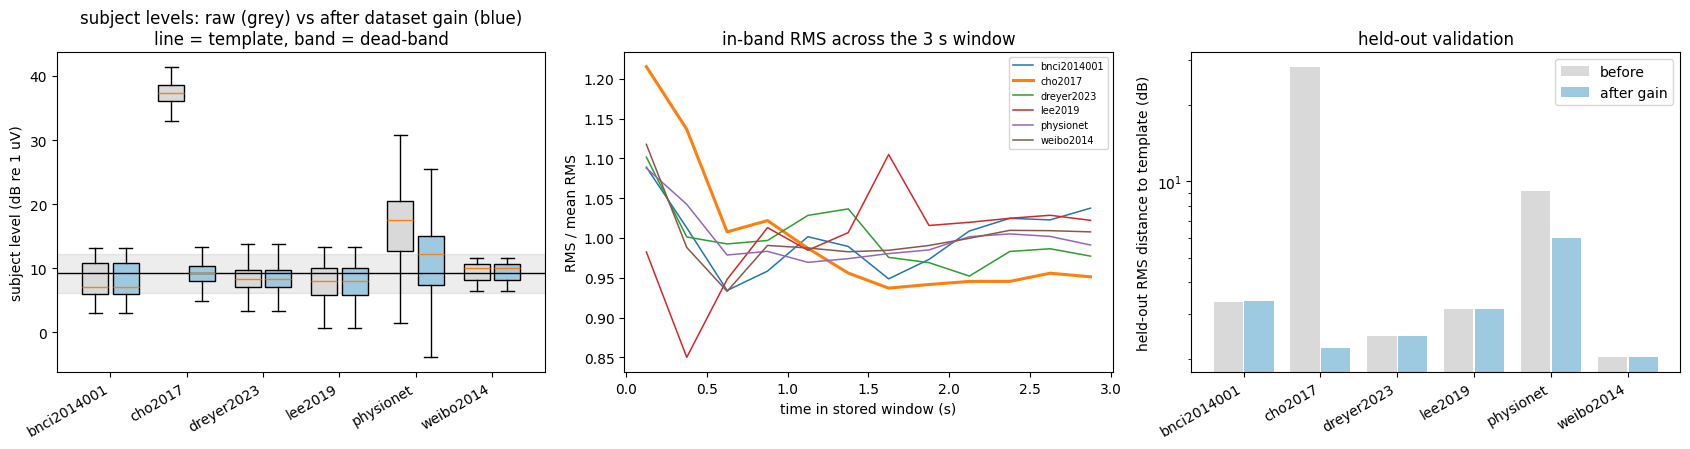

STANDARDIZATION STATUS: PASS   (53 checks, 2 warning(s))
template sha1 c48caed56e639274a3316a8c7ee7f05e2ba6110a
  [WARN] cho2017_author_qc_call_matches_package_signature: `_cho2017_qc_mask` calls get_cho2017_bad_trial_indices(subject) -> missing a required argument: 'mat_path'. The bare `except` returns 'keep all', so author-flagged bad trials were NOT excluded in v3 or v4. Not changed here: the package indexes trials chronologically while MOABB stacks Cho2017 as all
  [WARN] cho2017_author_qc_call_matches_package_signature: `_cho2017_qc_mask` calls get_cho2017_bad_trial_indices(subject) -> missing a required argument: 'mat_path'. The bare `except` returns 'keep all', so author-flagged bad trials were NOT excluded in v3 or v4. Not changed here: the package indexes trials chronologically while MOABB stacks Cho2017 as all


In [52]:
# --- Write the artifacts and close the gate -------------------------------------------------------------------------------
import shutil
CODE_ROOT = PROCESSED_ROOT / "code"
CODE_ROOT.mkdir(parents=True, exist_ok=True)
_code_src = Path(pkgstd.__file__)
_write_with_retry(shutil.copyfile, _code_src, CODE_ROOT / "standardization.py")
_code_sha1 = hashlib.sha1((CODE_ROOT / "standardization.py").read_bytes()).hexdigest()

template.provenance.update(pkgstd._to_py(dict(
    export_run_name=CFG.run_name, export_timestamp=pd.Timestamp.utcnow().isoformat(), code_path="code/standardization.py",
    code_sha1=_code_sha1, locked_test_sha1=hashlib.sha1("\n".join(sorted(locked_test_keys)).encode()).hexdigest(),
    freeze_guard=locked_freeze_note,
    validation=dict(heldout_level=val_tbl.round(3).to_dict("index"), dataset_id_probe=dict(raw=p_raw, after_gain=p_adj),
                    amplitude_gate_dataset_level_ok=amp_gate["dataset_level_ok"], n_self_tests=len(_tests)))))

STD_TEMPLATE_PATH = CONFIG_ROOT / "standard_template.json"
_write_with_retry(template.save, STD_TEMPLATE_PATH)
STD_TEMPLATE_SHA1 = template.sha1()
_write_with_retry((CONFIG_ROOT / "standard_template.sha1").write_text, STD_TEMPLATE_SHA1 + "\n")
_write_with_retry((CONFIG_ROOT / "STANDARD_TEMPLATE_USAGE.md").write_text, f"""# Using the standard template

The template is a hash-protected JSON file. It never modifies the shards; apply it at load time.

```python
import sys; sys.path.insert(0, "<processed>/code")          # or: import preprocessing_pkg.standardization
import standardization as std
tpl = std.StandardTemplate.load("<processed>/config/standard_template.json")   # raises if the file was edited

# one subject, shared-18 view, default arm ({CFG.standard.default_arm}); arms: {', '.join(pkgstd.ARM_NAMES)}
out = std.load_subject_standardized("<processed>", "data/cho2017/S001.npz", tpl, arm=None, view="shared18")
X, y = out["X"], out["y"]            # (n_trials, 18, {int(round(CFG.standard.model_window_s * CFG.preproc.target_sfreq))}) float32 ; Dreyer feedback runs already excluded
# masked62 view: out = ...(view="masked62"); out["X"] is (n, 62, L) with exact zeros at masked channels and out["mask"] is the (62,) bool mask

# training: std.StandardAugmenter(tpl, mask_library, seed).__call__(full_window_standardized_trial, mask)
# dataset sampling: tpl.core["sampling"]["dataset_probability"]
```

Fitted on the CV pool only (n={template.provenance['n_fit_subjects']}); locked-test subjects were excluded (sha1 of the locked set: {template.provenance['locked_test_sha1'][:12]}).
For final reported numbers, refit the template on the outer-train subjects of each split with `std.fit_distribution_template`.
Template sha1: {STD_TEMPLATE_SHA1}
""")

# round trip from disk
_t_disk = pkgstd.StandardTemplate.load(STD_TEMPLATE_PATH)
_a = pkgstd.load_subject_standardized(PROCESSED_ROOT, _acc_subjects[0]["shard_path"], template, view="masked62")["X"]
_b = pkgstd.load_subject_standardized(PROCESSED_ROOT, _acc_subjects[0]["shard_path"], _t_disk, view="masked62")["X"]
_s_record("template_roundtrip_from_disk", _t_disk.sha1() == STD_TEMPLATE_SHA1 and _t_disk.core == template.core and np.array_equal(_a, _b),
          f"sha1 {STD_TEMPLATE_SHA1[:12]}; transform output identical when re-loaded")
_s_record("code_snapshot_matches", hashlib.sha1((CODE_ROOT / "standardization.py").read_bytes()).hexdigest() == _code_sha1, f"code/standardization.py sha1 {_code_sha1[:12]}")

# tables + figure
level_table.round(4).to_csv  # (kept for display); the CSV below is the persisted copy
_write_with_retry(level_table.round(4).to_csv, QC_ROOT / "dataset_level_table.csv")
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
_order = sorted(subj_lv["dataset"].unique())
_adj = subj_lv.assign(after=subj_lv["level_db"] + subj_lv["dataset"].map(lambda d: template.gain_db(d, strict=False)))
_pos = np.arange(len(_order))
ax[0].boxplot([subj_lv.loc[subj_lv["dataset"] == d, "level_db"] for d in _order], positions=_pos - 0.2, widths=0.34, showfliers=False,
              patch_artist=True, boxprops=dict(facecolor="#d9d9d9"))
ax[0].boxplot([_adj.loc[_adj["dataset"] == d, "after"] for d in _order], positions=_pos + 0.2, widths=0.34, showfliers=False,
              patch_artist=True, boxprops=dict(facecolor="#9ecae1"))
ax[0].axhline(template.template_level_db, color="k", lw=1)
ax[0].axhspan(template.template_level_db - lvl["deadband_db"], template.template_level_db + lvl["deadband_db"], color="k", alpha=0.07)
ax[0].set_xticks(_pos); ax[0].set_xticklabels(_order, rotation=30, ha="right"); ax[0].set_ylabel("subject level (dB re 1 uV)")
ax[0].set_title("subject levels: raw (grey) vs after dataset gain (blue)\nline = template, band = dead-band")
for _d, _p in edge_profiles.items():
    ax[1].plot(np.arange(len(_p)) * 0.25 + 0.125, _p, label=_d, lw=2.2 if _d == "cho2017" else 1.1)
ax[1].set_xlabel("time in stored window (s)"); ax[1].set_ylabel("RMS / mean RMS"); ax[1].legend(fontsize=7); ax[1].set_title("in-band RMS across the 3 s window")
ax[2].bar(np.arange(len(val_tbl)) - 0.2, val_tbl["rms_before_db"], 0.38, label="before", color="#d9d9d9")
ax[2].bar(np.arange(len(val_tbl)) + 0.2, val_tbl["rms_after_db"], 0.38, label="after gain", color="#9ecae1")
ax[2].set_xticks(np.arange(len(val_tbl))); ax[2].set_xticklabels(val_tbl.index, rotation=30, ha="right")
ax[2].set_ylabel("held-out RMS distance to template (dB)"); ax[2].set_yscale("log"); ax[2].legend(); ax[2].set_title("held-out validation")
fig.tight_layout()
_write_with_retry(fig.savefig, QC_ROOT / "standardization_overview.png", dpi=130, bbox_inches="tight")
plt.show()

# stored_layout.json: point downstream readers at the template
_layout_path = META_ROOT / "stored_layout.json"
_layout = json.loads(_layout_path.read_text())
_layout["standardization"] = dict(
    template_path="config/standard_template.json", template_sha1=STD_TEMPLATE_SHA1, code_path="code/standardization.py",
    default_arm=template.default_arm, arms=list(template.core["arms"]), formula=template.core["transform_formula"],
    shared_support_channels=SHARED_NAMES, input_unit_uv=template.input_unit_uv,
    window=dict(start_s=_win["nominal_start_s"], length_s=_win["model_window_s"], train_shift_s=_win["train_shift_s"]),
    stored_arrays_modified=False, scale_window="full stored master window",
    sidecars=["metadata/trial_scale.parquet", "metadata/subject_channel_levels.npz"])
_write_with_retry(_layout_path.write_text, json.dumps(_layout, indent=2, default=str))

# close the gate
std_results["status"] = "pass" if all(c["passed"] for c in std_results["checks"] if c["severity"] == "fail") else "fail"
std_results["template_sha1"] = STD_TEMPLATE_SHA1
_write_with_retry((QC_ROOT / "standardization_report.json").write_text, json.dumps(std_results, indent=2, default=str))
_n_warn = sum(1 for c in std_results["checks"] if not c["passed"] and c["severity"] == "warn")
print("=" * 78)
print(f"STANDARDIZATION STATUS: {std_results['status'].upper()}   ({len(std_results['checks'])} checks, {_n_warn} warning(s))")
print(f"template sha1 {STD_TEMPLATE_SHA1}")
for _c in std_results["checks"]:
    if not _c["passed"] and _c["severity"] in ("fail", "warn"):
        print(f"  [{_c['severity'].upper()}] {_c['name']}: {_c['detail'][:300]}")
print("=" * 78)


### Gate — write final status

In [53]:
validation_results["status"] = "pass" if all(c["passed"] for c in validation_results["checks"]) else "fail"
_write_with_retry((VALIDATION_ROOT / "leakage_validation_report.json").write_text,
              json.dumps(validation_results, indent=2, default=str))
_write_with_retry((VALIDATION_ROOT / "grouped_vs_ungrouped.csv").write_text,
              leak_df.to_csv(index=False) if len(leak_df) else "")

qc_pass = qc_results["status"] == "pass"
val_pass = validation_results["status"] == "pass"
std_pass = std_results["status"] == "pass"   # v4: Section 9
export_complete = len(all_subject_rows) == total_planned

manifest = dict(
    run_name=CFG.run_name, preproc_id=CFG.preproc.preproc_id(),
    export_timestamp=pd.Timestamp.utcnow().isoformat(),
    n_datasets=len(subject_plan), n_subjects_planned=total_planned, n_subjects_exported=len(all_subject_rows),
    n_samples=N_SAMPLES, n_channels=len(TARGET_CHANNELS), target_sfreq=CFG.preproc.target_sfreq,
    master_window_sec=list(CFG.preproc.master_window), bandpass_hz=list(CFG.preproc.bandpass),
    trial_norm=CFG.preproc.trial_norm, stored_layout_path="metadata/stored_layout.json",
    n_trials=len(trials_df), qc_status=qc_results["status"], validation_status=validation_results["status"],
    standardization_status=std_results["status"], standard_template_path="config/standard_template.json",
    standard_template_sha1=STD_TEMPLATE_SHA1, standard_default_arm=CFG.standard.default_arm,
    dataset_summary={d: {k: v for k, v in s.items() if k != "failed"} for d, s in dataset_summary.items()},
)
_write_with_retry((PROCESSED_ROOT / "manifest.json").write_text, json.dumps(manifest, indent=2, default=str))

if qc_pass and val_pass and export_complete and std_pass:
    _write_with_retry((PROCESSED_ROOT / "STATUS.txt").write_text, "READY_FOR_TRAINING\n")
    print("=" * 70)
    print(f"STATUS: READY_FOR_TRAINING")
    print(f"  {len(all_subject_rows)} subjects, {len(trials_df)} trials, "
          f"preproc_id={CFG.preproc.preproc_id()}")
    print(f"  processed/ -> {PROCESSED_ROOT}")
    print(f"  standard template: config/standard_template.json  sha1={STD_TEMPLATE_SHA1[:12]}  default_arm={CFG.standard.default_arm}")
    print("=" * 70)
else:
    reasons = []
    if not export_complete:
        reasons.append(f"export incomplete: {len(all_subject_rows)}/{total_planned} subjects "
                        f"({sum(s['n_failed'] for s in dataset_summary.values())} failed)")
    if not qc_pass:
        reasons.append("QC gate failed -- see qc/qc_report.json")
    if not val_pass:
        reasons.append("leakage validation failed -- see validation/leakage_validation_report.json")
    if not std_pass:
        reasons.append("standard-template gate failed -- see qc/standardization_report.json")
    _write_with_retry((PROCESSED_ROOT / "STATUS.txt").write_text, "FAILED\n" + "\n".join(reasons) + "\n")
    print("=" * 70)
    print("STATUS: FAILED -- do not train on this export.")
    for r in reasons:
        print(" -", r)
    print("=" * 70)


STATUS: READY_FOR_TRAINING
  316 subjects, 50847 trials, preproc_id=b202f261d85f
  processed/ -> /content/drive/MyDrive/MI_EEG_Datasets/Processed
  standard template: config/standard_template.json  sha1=c48caed56e63  default_arm=B_T2


## Section 10 — Summary

`processed/STATUS.txt` is the single file worth checking before starting Stage 3
(baseline training). If it reads `READY_FOR_TRAINING`, everything under `processed/`
-- shards, metadata, config, channel tables, QC report, split manifests and the
leakage-validation report -- is self-consistent and stamped with the same
`preproc_id`. If it reads `FAILED`, the listed reasons point at exactly which gate
did not pass; re-run only what is needed (a fresh QC pass reads shards already on
disk and does not require re-downloading or re-exporting anything that already
passed).

**v4 addition.** `processed/config/standard_template.json` (hash-protected), `processed/code/standardization.py` (the exact code that produced it), `processed/qc/standardization_report.json` and `processed/config/STANDARD_TEMPLATE_USAGE.md` are part of the frozen export. `READY_FOR_TRAINING` now also means Section 9 passed.

In [ ]:
print(Path(PROCESSED_ROOT, "STATUS.txt").read_text())
def _tree(root, prefix=""):
    entries = sorted(Path(root).iterdir())
    for i, p in enumerate(entries):
        connector = "+-- " if i < len(entries) - 1 else "\\-- "
        print(prefix + connector + p.name + ("/" if p.is_dir() else ""))
        if p.is_dir() and prefix.count("|") < 2:
            _tree(p, prefix + ("|   " if i < len(entries) - 1 else "    "))
_tree(PROCESSED_ROOT)


In [3]:
import sys, json, numpy as np, pandas as pd
from pathlib import Path
P = Path("/content/drive/MyDrive/MI_EEG_Datasets/Processed")
sys.path.insert(0, str(P / "code")); import standardization as pkgstd
template = pkgstd.StandardTemplate.load(P / "config" / "standard_template.json")
trial_scale_df = pd.read_parquet(P / "metadata" / "trial_scale.parquet")
subjects_df = pd.read_parquet(P / "metadata" / "subjects.parquet")
subjects_df["subject_key"] = subjects_df["dataset"] + ":" + subjects_df["subject_id"].astype(str)
locked_test_keys = set(json.loads((P / "splits" / "locked_test_subjects.json").read_text()))
cv_pool_df = subjects_df[~subjects_df["subject_key"].isin(locked_test_keys)]
subj_lv = pkgstd.subject_level_table(trial_scale_df, set(cv_pool_df["subject_key"]))
amp_gate = pkgstd.amplitude_gate(subj_lv, template)

In [5]:
# ======================================================================================================================
# POST-RUN VERIFICATION of the standard template (read-only: writes nothing). Paste after the last Section 9 cell.
# Uses only objects Section 9 already built: trial_scale_df, template, subj_lv, amp_gate, cv_pool_df, locked_test_keys.
# ======================================================================================================================
import numpy as np, pandas as pd, json
from pathlib import Path

T = template.template_level_db
cfgd = template.config
alpha_C = template.arm_spec("C_gain_tempered")["alpha"]; clip_C = template.arm_spec("C_gain_tempered")["clip_db"]

# --- 1. population-level effect of every arm (all CV-pool subjects, not the 2-subject acceptance sample) -------------------
lv = subj_lv.copy()
lv["gain"] = lv["dataset"].map(lambda d: template.gain_db(d, strict=False))
E = lv["level_db"] - T                     # arm E: raw
A = E + lv["gain"]                          # arm A: dataset gain
C = A + (-alpha_C * A).clip(-clip_C, clip_C)  # arm C (subject-median approximation of the per-trial rule)
B = E * 0.0                                 # arm B: every trial at the template by construction
rows = []
for d in sorted(lv["dataset"].unique()):
    m = (lv["dataset"] == d).to_numpy()
    r = dict(dataset=d, n=int(m.sum()))
    for name, v in (("E_raw", E), ("A_gain", A), ("C_tempered", C)):
        x = v[m]
        r[f"{name}_median"] = x.median(); r[f"{name}_sd"] = x.std(ddof=1)
    rows.append(r)
pop = pd.DataFrame(rows).set_index("dataset")
print("1) subject level relative to the template, dB (median / SD across ALL CV-pool subjects); arm B is 0 / 0 by construction")
display(pop.round(2))

# --- 2. trial-level spread and outlier rate after the dataset gain --------------------------------------------------------
cvk = set(cv_pool_df["subject_key"])
tr = trial_scale_df[trial_scale_df["subject_key"].isin(cvk) & ~trial_scale_df["feedback_confounded"].astype(bool)
                    & np.isfinite(trial_scale_df["level_db"])].copy()
tr["dev"] = tr["level_db"] + tr["dataset"].map(lambda d: template.gain_db(d, strict=False)) - T
within = tr.groupby(["dataset", "subject_key"])["level_db"].std(ddof=1).groupby("dataset").median()
out_rate = tr.groupby("dataset")["dev"].apply(lambda s: float((s.abs() > cfgd["outlier_flag_db"]).mean()))
big_rate = tr.groupby("dataset")["dev"].apply(lambda s: float((s.abs() > cfgd["tempered_clip_db"] + 3.0).mean()))
t2 = pd.DataFrame({"trial_sd_within_subject_db": within, f"frac_|dev|>{cfgd['outlier_flag_db']:.0f}dB (flagged)": out_rate,
                   f"frac_|dev|>{cfgd['tempered_clip_db'] + 3.0:.0f}dB": big_rate})
print("\n2) trial-level spread (design assumed ~1.6 dB within subject) and outlier rates after the dataset gain")
display(t2.round(4))

# --- 3. the widest dataset: shape of its subject-level distribution and who the amplitude gate flagged ---------------------
wide = pop["E_raw_sd"].idxmax()
x = lv.loc[lv["dataset"] == wide, "level_db"]
q = x.quantile([0, .05, .25, .5, .75, .95, 1]).round(2)
print(f"\n3) widest dataset = {wide}: SD {x.std(ddof=1):.2f} dB, mean-median {x.mean() - x.median():+.2f} dB, quantiles (0/5/25/50/75/95/100%):")
print("   ", q.tolist())
fl = lv[lv["subject_key"].isin(amp_gate["flagged_keys"])][["subject_key", "level_db"]].assign(dev_after_gain_db=lambda t: t["level_db"] + t["subject_key"].str.split(":").str[0].map(
    lambda d: template.gain_db(d, strict=False)) - T)
print("   subjects beyond the +-%.0f dB subject gate:" % cfgd["amp_gate_subject_db"]); display(fl.round(2))
share_out = (A.abs() > template.core["level"]["deadband_db"]).groupby(lv["dataset"]).mean()
print("   share of subjects still outside the dead-band after the dataset gain (arm A):", share_out.round(2).to_dict())

# --- 4. locked-set identity vs the set used by the distribution analysis (set the path to your earlier file) -------------
PREV_LOCKED_PATH = "/content/drive/MyDrive/MI_EEG_Datasets/processed/splits/locked_test_subjects.json"        # e.g. "/content/drive/MyDrive/MI_EEG_Datasets/processed/splits/locked_test_subjects.json"
if PREV_LOCKED_PATH and Path(PREV_LOCKED_PATH).exists():
    prev = set(json.loads(Path(PREV_LOCKED_PATH).read_text()))
    print(f"\n4) locked set identical to the earlier file: {prev == set(locked_test_keys)}  "
          f"(only-in-earlier {len(prev - set(locked_test_keys))}, only-in-this-run {len(set(locked_test_keys) - prev)})")
else:
    print("\n4) set PREV_LOCKED_PATH to your earlier locked_test_subjects.json to confirm the CV pool is the one the analysis used.")


1) subject level relative to the template, dB (median / SD across ALL CV-pool subjects); arm B is 0 / 0 by construction


,n,E_raw_median,E_raw_sd,A_gain_median,A_gain_sd,C_tempered_median,C_tempered_sd
dataset,,,,,,,
bnci2014001,8,-2.09,3.38,-2.09,3.38,-1.05,1.69
cho2017,44,28.11,2.17,-0.00,2.17,-0.00,1.09
dreyer2023,73,-0.85,2.36,-0.85,2.36,-0.43,1.18
lee2019,46,-1.24,2.83,-1.24,2.83,-0.62,1.42
physionet,89,8.37,5.74,3.00,5.74,1.50,2.96
weibo2014,8,0.85,1.88,0.85,1.88,0.43,0.94



2) trial-level spread (design assumed ~1.6 dB within subject) and outlier rates after the dataset gain


,trial_sd_within_subject_db,frac_|dev|>20dB (flagged),frac_|dev|>9dB
dataset,,,
bnci2014001,1.0951,0.0000,0.0000
cho2017,1.1097,0.0000,0.0007
dreyer2023,1.0656,0.0002,0.0014
lee2019,1.5054,0.0000,0.0084
physionet,1.2908,0.0000,0.1202
weibo2014,1.5282,0.0000,0.0000



3) widest dataset = physionet: SD 5.74 dB, mean-median -1.31 dB, quantiles (0/5/25/50/75/95/100%):
    [1.5, 5.93, 12.75, 17.59, 20.44, 23.36, 30.82]
   subjects beyond the +-12 dB subject gate:


,subject_key,level_db,dev_after_gain_db
181,physionet:109,30.82,16.23
217,physionet:51,1.50,-13.10


   share of subjects still outside the dead-band after the dataset gain (arm A): {'bnci2014001': 0.38, 'cho2017': 0.18, 'dreyer2023': 0.22, 'lee2019': 0.35, 'physionet': 0.73, 'weibo2014': 0.0}

4) locked set identical to the earlier file: True  (only-in-earlier 0, only-in-this-run 0)
